# Diabetes Health Indicators
# Lab 1: Exploratory Data Analysis

## BRFSS 2015 Diabetes Health Indicators Dataset

**Project Team:** Harvey, Sydney, Wolfgang, Nashita
**Course:** Intro to AI
**Date:** September 2026



# 1. Introduction

## 1.1 Purpose of the Dataset

The purpose of this dataset is to better understand the relationship between
lifestyle, health conditions, demographic characteristics, and diabetes in the
United States.

The data comes from the Behavioral Risk Factor Surveillance System (BRFSS), an
annual telephone survey run by state health departments in collaboration with
the CDC. It records health behaviors, health conditions, access to healthcare,
and demographic characteristics as reported by the respondents themselves. Every
field is self-reported over the phone, and that collection method introduces
biases that are discussed further in the EDA.

The 2015 BRFSS release contains 441,455 respondents and 330 variables. The
version used here is a cleaned subset published on Kaggle by Alex Teboul, who
reduced it to 253,680 respondents and 21 features known to be associated with
diabetes, plus the diabetes target. The feature selection is his, not the CDC's,
which is itself a modeling decision worth keeping in mind.

The result is large and mostly clean, with no missing values and no outstanding
outliers. A few data quality issues remain, and these are noted in the EDA.
Overall the data is plentiful, rich, and a pleasure to work with. Nevertheless,
there are limits to the scope of inference.

The dataset is useful because diabetes is an important public health concern, and
understanding which characteristics are associated with it helps identify
populations that may be at higher risk.

The primary question for this analysis is:

> **Which health, lifestyle, and demographic characteristics are most strongly
> associated with a diabetes or prediabetes diagnosis?**

A secondary goal is to determine whether these characteristics can be used to
build a machine-learning model that usefully ranks individuals by diabetes risk
and, as Section 15.3 explores, whether that ranking can point to people whose
diabetes is real but undiagnosed.

## 1.2 Defining and Measuring the Outcome

The raw outcome variable in the source file is `Diabetes_012`, which records the
respondent's answer to whether a doctor has ever told them they have diabetes:

| Value | Meaning | Count | Share |
|---:|---|---:|---:|
| 0 | No diabetes | 213,703 | 84.24% |
| 1 | Prediabetes | 4,631 | 1.83% |
| 2 | Diabetes | 35,346 | 13.93% |

We approach the problem as binary classification, collapsing `Prediabetes` and
`Diabetes` into a single positive class with a prevalence of 15.76%. This follows
the framing of Kaggle's own binary release of the dataset.

Note that the variable measures *diagnosis*, not disease. A respondent who has
diabetes but has never been screened is coded as a negative case. Section 15.3
takes up this distinction directly.

## 1.3 Measuring the Effectiveness of a Prediction Algorithm

This is an imbalanced dataset with a no information rate of 85%. Accuracy is insufficient to evaluate model performance. Downstream, models will use the standard classification metrics.

| Metric | What it measures | Why it matters here |
|---|---|---|
| **Recall (sensitivity)** | Of people with diabetes, what share did we flag? | A missed diabetic goes untreated. This is the costliest error. |
| **Precision** | Of the people we flagged, what share truly have diabetes? | Governs how much screening capacity is wasted on false alarms. |
| **F1-score** | Harmonic mean of precision and recall | Single number when both errors matter, but it hides which one dominates. |
| **ROC-AUC** | Ranking quality across all thresholds | Threshold-independent, but optimistic under heavy imbalance. |
| **PR-AUC** | Precision-recall tradeoff across thresholds | More informative than ROC-AUC when positives are rare. Preferred here. |
| **Balanced accuracy** | Mean of per-class recall | Reports whether the minority class is handled at all. |
| **Brier score** | Mean squared error of the predicted probability | The MSE-style metric from the original answer, applied to a probability instead of a hard label (Section 15.3). |

# 2. Setup and Data Loading

In [52]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "600"


PALETTE = {
    "ink":    "#22303c",
    "grid":   "#dfe4e8",
    "neg":    "#8fa3b0",   # reference / unexposed
    "pos":    "#b5442e",   # diabetes / elevated
    "prot":   "#2f6f6a",   # protective direction
    "accent": "#c98a1b",
}

# Ordered three-class charts: no diabetes / prediabetes / diabetes.
PALETTE_012 = [PALETTE["neg"], PALETTE["accent"], PALETTE["pos"]]

# The matching continuous scale. Its dark end is PALETTE["pos"], so a dark heatmap
# cell and a "pos" bar carry the same meaning.
SEQ = sns.blend_palette(["#f5f2ea", "#d8b26a", PALETTE["pos"], "#5c1d13"], as_cmap=True)

def seq_colors(n, lo=0.30, hi=0.92):
    """Evenly spaced steps along SEQ, for ordered series such as age bands."""
    return [SEQ(v) for v in np.linspace(lo, hi, n)]


print("Libraries imported successfully.")

Libraries imported successfully.


In [53]:
raw = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")

print(f"rows    : {raw.shape[0]:,}")
print(f"columns : {raw.shape[1]}")

rows    : 253,680
columns : 22


We build the binary target here, immediately after
loading, so every section from this point on works against the same column. The
original three-class column is kept as `Diabetes_012` for the places where
showing where prediabetes sits is the point.

In [54]:
# Diabetes_012: 0 = no diabetes, 1 = prediabetes, 2 = diabetes (self-reported diagnosis)
# Decision #1: collapse to Diabetes_binary = 1 for prediabetes OR diabetes.
raw["Diabetes_binary"] = (raw["Diabetes_012"] >= 1).astype(int)

TARGET   = "Diabetes_binary"
FEATURES = [c for c in raw.columns if c not in ("Diabetes_012", "Diabetes_binary")]

print(f"target     : {TARGET}, prevalence {100*raw[TARGET].mean():.2f}%")
print(f"features   : {len(FEATURES)}")
print(f"3-class counts for reference:")
print(raw.Diabetes_012.value_counts().sort_index().rename({0:"no diabetes",1:"prediabetes",2:"diabetes"}))

target     : Diabetes_binary, prevalence 15.76%
features   : 21
3-class counts for reference:
Diabetes_012
no diabetes    213703
prediabetes      4631
diabetes        35346
Name: count, dtype: int64


# 3. Data Understanding

In [55]:
raw.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.000,1.000,1.000,1.000,40.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,5.000,18.000,15.000,1.000,0.000,9.000,4.000,3.000,0
1,0.000,0.000,0.000,0.000,25.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,3.000,0.000,0.000,0.000,0.000,7.000,6.000,1.000,0
2,0.000,1.000,1.000,1.000,28.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,1.000,5.000,30.000,30.000,1.000,0.000,9.000,4.000,8.000,0
3,0.000,1.000,0.000,1.000,27.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,0.000,11.000,3.000,6.000,0
4,0.000,1.000,1.000,1.000,24.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,3.000,0.000,0.000,0.000,11.000,5.000,4.000,0
5,0.000,1.000,1.000,1.000,25.000,1.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,0.000,2.000,0.000,1.000,10.000,6.000,8.000,0
6,0.000,1.000,0.000,1.000,30.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,3.000,0.000,14.000,0.000,0.000,9.000,6.000,7.000,0
7,0.000,1.000,1.000,1.000,25.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,3.000,0.000,0.000,1.000,0.000,11.000,4.000,4.000,0
8,2.000,1.000,1.000,1.000,30.000,1.000,0.000,1.000,0.000,1.000,1.000,0.000,1.000,0.000,5.000,30.000,30.000,1.000,0.000,9.000,5.000,1.000,1
9,0.000,0.000,0.000,1.000,24.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,1.000,8.000,4.000,3.000,0


In [56]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

## 3.1 Attribute Descriptions

Every column in this file is stored as `float64`, but that storage type is
misleading, because only one variable, BMI, is a true continuous measurement. The
rest are binary flags or integer codes standing in for categories, and several
of those codes are ordered, which changes how they should be treated.

The `Scale` column below uses the standard measurement-scale terms, because the
scale determines which statistics are meaningful. Computing a mean of a nominal
code is meaningless; computing one for an ordinal code is only interpretable with
care.

| # | Attribute | Type | Scale | Values | Description |
|---:|---|---|---|---|---|
| 1 | `Diabetes_binary` | Categorical | Nominal | 0, 1 | **Target.** 1 = prediabetes or diagnosed diabetes (`Diabetes_012 >= 1`); 0 = neither. See Decision #1. |
| 2 | `HighBP` | Binary | Nominal | 0, 1 | Ever told by a health professional they have high blood pressure. |
| 3 | `HighChol` | Binary | Nominal | 0, 1 | Ever told they have high cholesterol. |
| 4 | `CholCheck` | Binary | Nominal | 0, 1 | Cholesterol checked within the past 5 years. |
| 5 | `BMI` | Numeric | Ratio | 12-98 | Body Mass Index, derived from self-reported height and weight. See Section 4.3 for capping. |
| 6 | `Smoker` | Binary | Nominal | 0, 1 | Smoked >= 100 cigarettes in lifetime. **Not** current smoking status. |
| 7 | `Stroke` | Binary | Nominal | 0, 1 | Ever told they had a stroke. |
| 8 | `HeartDiseaseorAttack` | Binary | Nominal | 0, 1 | Ever reported CHD or myocardial infarction. |
| 9 | `PhysActivity` | Binary | Nominal | 0, 1 | Any physical activity in past 30 days outside of work. |
| 10 | `Fruits` | Binary | Nominal | 0, 1 | Consumes fruit >=1 time per day. |
| 11 | `Veggies` | Binary | Nominal | 0, 1 | Consumes vegetables >=1 time per day. |
| 12 | `HvyAlcoholConsump` | Binary | Nominal | 0, 1 | Heavy drinker (M > 14, F > 7 drinks/week). |
| 13 | `AnyHealthcare` | Binary | Nominal | 0, 1 | Has any health care coverage. |
| 14 | `NoDocbcCost` | Binary | Nominal | 0, 1 | Needed a doctor in past 12m but could not afford one. |
| 15 | `GenHlth` | Ordinal | Ordinal | 1-5 | Self-rated general health: 1 = Excellent ... 5 = Poor. |
| 16 | `MentHlth` | Count | Interval-ish | 0-30 | Days in past 30 mental health was not good. Zero-inflated — see Section 4.4. |
| 17 | `PhysHlth` | Count | Interval-ish | 0-30 | Days in past 30 physical health was not good. Zero-inflated — see Section 4.4. |
| 18 | `DiffWalk` | Binary | Nominal | 0, 1 | Serious difficulty walking or climbing stairs. |
| 19 | `Sex` | Binary | Nominal | 0, 1 | 0 = female, 1 = male. |
| 20 | `Age` | Ordinal | Ordinal | 1-13 | 13 five-year age bands, 18-24 through 80+. |
| 21 | `Education` | Ordinal | Ordinal | 1-6 | Highest grade or year of school completed. |
| 22 | `Income` | Ordinal | Ordinal | 1-8 | Household income bracket. |

`CholCheck`, `AnyHealthcare`, and `NoDocbcCost` deserve a flag up front because portions of the EDA treat them as healthcare-*access* variables rather than health variables,
because they measure contact with the health system, not the underlying condition.

In [57]:
# Confirm the coded ranges match the documentation above (codebook audit)
EXPECTED = {"Diabetes_binary":(0,1), "Diabetes_012":(0,2), "HighBP":(0,1), "HighChol":(0,1),
            "CholCheck":(0,1), "BMI":(12,98), "Smoker":(0,1), "Stroke":(0,1),
            "HeartDiseaseorAttack":(0,1), "PhysActivity":(0,1), "Fruits":(0,1),
            "Veggies":(0,1), "HvyAlcoholConsump":(0,1), "AnyHealthcare":(0,1),
            "NoDocbcCost":(0,1), "GenHlth":(1,5), "MentHlth":(0,30), "PhysHlth":(0,30),
            "DiffWalk":(0,1), "Sex":(0,1), "Age":(1,13), "Education":(1,6), "Income":(1,8)}

audit = pd.DataFrame({
    "min":            raw.min(),
    "max":            raw.max(),
    "n_unique":       raw.nunique(),
    "non_integer":    [(raw[c] % 1 != 0).sum() for c in raw.columns],
})
audit["codebook"] = [f"{EXPECTED[c][0]}-{EXPECTED[c][1]}" for c in raw.columns]
audit["in_range"] = [bool(raw[c].between(*EXPECTED[c]).all()) for c in raw.columns]

display(audit)
print(f"columns outside codebook range : {(~audit.in_range).sum()}")
print(f"non-integer values anywhere    : {audit.non_integer.sum()}")

,min,max,n_unique,non_integer,codebook,in_range
Diabetes_012,0.000,2.000,3,0,0-2,True
HighBP,0.000,1.000,2,0,0-1,True
HighChol,0.000,1.000,2,0,0-1,True
CholCheck,0.000,1.000,2,0,0-1,True
BMI,12.000,98.000,84,0,12-98,True
Smoker,0.000,1.000,2,0,0-1,True
Stroke,0.000,1.000,2,0,0-1,True
HeartDiseaseorAttack,0.000,1.000,2,0,0-1,True
PhysActivity,0.000,1.000,2,0,0-1,True
Fruits,0.000,1.000,2,0,0-1,True


columns outside codebook range : 0
non-integer values anywhere    : 0


The observed ranges match the documented codings exactly. There are no
out-of-range values, no negative entries, and no sentinel codes such as 7, 9, or
99 (the "don't know / refused" markers used in the raw BRFSS). This confirms the
file is a pre-cleaned extract rather than the raw survey a point Section 5
returns to when comparing this sample against the general population, since
roughly 43% of the original BRFSS respondents are absent by construction (incomplete
records were filtered out before this CSV was written).

## 3.2 Simple, Appropriate Statistics for Key Attributes

Range, mode, mean, median, and variance mean different things depending on a
variable's measurement scale (Section 3.1), so this section reports the
statistic that's actually appropriate for each key attribute rather than running
`.describe()` on everything uniformly.

- `BMI` is the one true continuous/ratio variable: mean, median, and variance
  all apply.
- `GenHlth`, `Age`, `Education`, `Income` are ordinal: median and mode are
  meaningful; a mean is only cautiously interpretable (it assumes equal spacing
  between categories, which Section 7.3's Age curve shows isn't quite true).
- `MentHlth`, `PhysHlth` are counts with a zero-inflated, bimodal shape (Section
  4.4 revisits this): the mean is reported here for completeness but is flagged
  as potentially misleading on its own.
- The binary indicators (`HighBP`, `HighChol`, `Smoker`, etc.) are nominal: only a
  proportion/count is meaningful, not a mean, median, or variance in the usual
  sense (their "mean" is just their proportion of 1s, shown here for reference).

In [58]:
key_numeric = ["BMI", "GenHlth", "Age", "Education", "Income", "MentHlth", "PhysHlth"]

stats_table = pd.DataFrame({
    "count":    raw[key_numeric].count(),
    "min":      raw[key_numeric].min(),
    "max":      raw[key_numeric].max(),
    "mode":     raw[key_numeric].mode().iloc[0],
    "median":   raw[key_numeric].median(),
    "mean":     raw[key_numeric].mean(),
    "variance": raw[key_numeric].var(),
    "std":      raw[key_numeric].std(),
})
display(stats_table.round(2))

binary_like = [c for c in FEATURES if raw[c].nunique() == 2 and c != "Sex"]
prop_table = pd.DataFrame({
    "count_1":    raw[binary_like].sum().astype(int),
    "proportion": raw[binary_like].mean(),
}).sort_values("proportion", ascending=False)
display(prop_table.round(3))

,count,min,max,mode,median,mean,variance,std
BMI,253680,12.000,98.000,27.000,27.000,28.380,43.670,6.610
GenHlth,253680,1.000,5.000,2.000,2.000,2.510,1.140,1.070
Age,253680,1.000,13.000,9.000,8.000,8.030,9.330,3.050
Education,253680,1.000,6.000,6.000,5.000,5.050,0.970,0.990
Income,253680,1.000,8.000,8.000,7.000,6.050,4.290,2.070
MentHlth,253680,0.000,30.000,0.000,0.000,3.180,54.950,7.410
PhysHlth,253680,0.000,30.000,0.000,0.000,4.240,76.000,8.720


,count_1,proportion
CholCheck,244210,0.963
AnyHealthcare,241263,0.951
Veggies,205841,0.811
PhysActivity,191920,0.757
Fruits,160898,0.634
Smoker,112423,0.443
HighBP,108829,0.429
HighChol,107591,0.424
DiffWalk,42675,0.168
HeartDiseaseorAttack,23893,0.094


### What these numbers mean

Among the continuous and ordinal variables, `BMI` carries the most weight. Its
mean (28.4) sits above its median (27.0), signifying right skew: the bulk of
respondents cluster just above the healthy range, while a long tail climbs into
severe obesity. `MentHlth` and `PhysHlth` skew the same direction and more
sharply. Both have a mode of zero, meaning most respondents report no bad days
at all, but a heavy-tailed minority reporting many pulls each mean well above the
typical respondent. `GenHlth`'s mode falls in a healthier category than its mean
alone would suggest, consistent with self-rated health skewing positive. `Age`'s
median band sits solidly in middle age, and `Income` and `Education` both
concentrate at the higher end of their scales.

The self-reported picture is an optimistic one. Most respondents report regular
physical activity and daily fruit and vegetable consumption. Heavy drinking is
rare, general health is typically rated Good or better, and reported mental and
physical health days are mostly unblemished. Access to care is near-universal:
`CholCheck` is the most common behavior in the dataset, with nearly everyone
reporting a cholesterol screening in the past five years, while `Stroke` and
`HvyAlcoholConsump` are the rarest indicators.

Against that backdrop, a substantial share of respondents carry real risk. Around
42% report high blood pressure, and a similar share report high cholesterol. The
more severe correlates of diabetes - stroke, heart disease, difficulty walking —
appear in a much smaller minority. These conditions travel together, and they do
so independently of diabetes: hypertension and high cholesterol co-occur in
plenty of people who will never develop it. Separating the signal that is
specific to diabetes from the shared metabolic background is a central difficulty
of the modeling task.

### External comparison: is 15.8% a plausible number?

The CDC's 2017 National Diabetes Statistics Report, using 2015 data from the same
year this BRFSS extract is drawn from, estimated that 12.2% of US adults had
diabetes (diagnosed or undiagnosed) in 2015, of which about 23.8% were
undiagnosed. That puts *diagnosed* diabetes among US adults at roughly 9.3%
nationally.

The two halves of this sample's positive class compare very differently against
that benchmark. Diagnosed diabetes alone is 13.9% here, noticeably above the 9.3%
national figure, which is what a sample skewed towards older respondents would
produce (Section 5). Prediabetes is the opposite problem: 1.8% here against a
national estimate near a third of all adults, because prediabetes is
overwhelmingly undiagnosed and this variable records only what a respondent was
told. The combined 15.8% is therefore not an estimate of how common dysglycemia
is; it is a count of people who received one of two diagnoses, and it undercounts
the second one severely.

# 4. Data Quality and Cleaning

## 4.1 Missing Values

In [59]:
missing = raw.isnull().sum()
print(f"Total missing values across all columns: {missing.sum()}")
print(f"Columns with any missing: {(missing > 0).sum()}")

Total missing values across all columns: 0
Columns with any missing: 0


There are zero missing values, which almost certainly means the incomplete
records were cleaned out before this extract was published (consistent with the
~43% of original BRFSS respondents missing from this file).
This also means any conclusions here generalize only to respondents who fully
completed the survey, not to the original BRFSS sample.

## 4.2 Duplicate Rows

In [60]:
dup_any  = raw.duplicated(subset=FEATURES + [TARGET], keep=False)
dup_drop = raw.duplicated(subset=FEATURES + [TARGET])

print(f"rows                                 : {len(raw):,}")
print(f"rows drop_duplicates() would remove  : {dup_drop.sum():,} ({100*dup_drop.mean():.1f}%)")
print(f"rows belonging to a repeated profile  : {dup_any.sum():,}")
print(f"largest identical group              : "
      f"{raw.groupby(FEATURES + [TARGET], observed=True).size().max():,} rows")

rows                                 : 253,680
rows drop_duplicates() would remove  : 23,968 (9.4%)
rows belonging to a repeated profile  : 35,212
largest identical group              : 59 rows


There's evidence of duplicate rows where the values are the exact same across
every variable, with the exception, of course, of whatever row index the source
file assigned. If we assume these are mistakes and remove them, we would be
artificially removing a large number of healthy participants from the dataset.
Even though the duplicates are real, our inclination is not to remove them and
below we verify that inclination rather than just asserting it.

In [61]:
# Quantify what dropping duplicates would do to the headline rate
full_rate = 100 * raw[TARGET].mean()
dedup     = raw.drop_duplicates(subset=FEATURES + [TARGET])
dedup_rate = 100 * dedup[TARGET].mean()

print(f"Diabetes rate, all {len(raw):,} rows        : {full_rate:.2f}%")
print(f"Diabetes rate, {len(dedup):,} distinct rows : {dedup_rate:.2f}%")
print(f"Difference                                   : {dedup_rate - full_rate:+.2f} percentage points")

Diabetes rate, all 253,680 rows        : 15.76%
Diabetes rate, 229,712 distinct rows : 17.26%
Difference                                   : +1.50 percentage points


In [62]:
# Wolfgang's fuller comparison: repeated-profile rows vs. unique rows, side by side
COND5 = ["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack", "DiffWalk"]

comp = pd.DataFrame({
    "in a repeated profile": [
        dup_any.sum(),
        100 * raw.loc[dup_any, TARGET].mean(),
        raw.loc[dup_any, "BMI"].mean(),
        raw.loc[dup_any, "Age"].mean(),
        raw.loc[dup_any, COND5].sum(axis=1).mean(),
        100 * ((raw.loc[dup_any, "PhysHlth"] == 0) & (raw.loc[dup_any, "MentHlth"] == 0)).mean()],
    "unique row": [
        (~dup_any).sum(),
        100 * raw.loc[~dup_any, TARGET].mean(),
        raw.loc[~dup_any, "BMI"].mean(),
        raw.loc[~dup_any, "Age"].mean(),
        raw.loc[~dup_any, COND5].sum(axis=1).mean(),
        100 * ((raw.loc[~dup_any, "PhysHlth"] == 0) & (raw.loc[~dup_any, "MentHlth"] == 0)).mean()]},
    index=["n rows", "diabetes prevalence %", "mean BMI", "mean age band",
           "mean count of 5 comorbidities", "% reporting 0 bad mental AND physical days"])

display(comp.round(2))

,in a repeated profile,unique row
n rows,35212.000,218468.000
diabetes prevalence %,1.730,18.020
mean BMI,25.670,28.820
mean age band,7.620,8.100
mean count of 5 comorbidities,0.500,1.260
% reporting 0 bad mental AND physical days,92.360,42.780


This confirms the concern raised above. De-duplicating would raise the apparent
diabetes rate which would be an artifact of preferentially deleting healthy respondents, not a
real change in prevalence. The profile comparison makes the mechanism explicit:
rows in a repeated profile skew younger, leaner, and carry fewer comorbidities and
fewer reported bad-health days than unique rows. 

## 4.3 Outliers: The BMI Tail

In [63]:
bmi_desc = raw.BMI.describe()
print("BMI distribution:")
print(bmi_desc.to_string())
print()
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  {p:>5}th percentile: {np.percentile(raw.BMI, p):.0f}")
print()
print(f"BMI > 50: {int((raw.BMI > 50).sum()):,} rows ({100*(raw.BMI>50).mean():.2f}%)")
print(f"BMI > 60: {int((raw.BMI > 60).sum()):,} rows")
print(f"BMI > 70: {int((raw.BMI > 70).sum()):,} rows")
print(f"BMI < 15: {int((raw.BMI < 15).sum()):,} rows")

BMI distribution:
count   253680.000
mean        28.382
std          6.609
min         12.000
25%         24.000
50%         27.000
75%         31.000
max         98.000

     50th percentile: 27
     75th percentile: 31
     90th percentile: 36
     95th percentile: 40
     99th percentile: 50
   99.9th percentile: 81

BMI > 50: 2,175 rows (0.86%)
BMI > 60: 805 rows
BMI > 70: 584 rows
BMI < 15: 68 rows


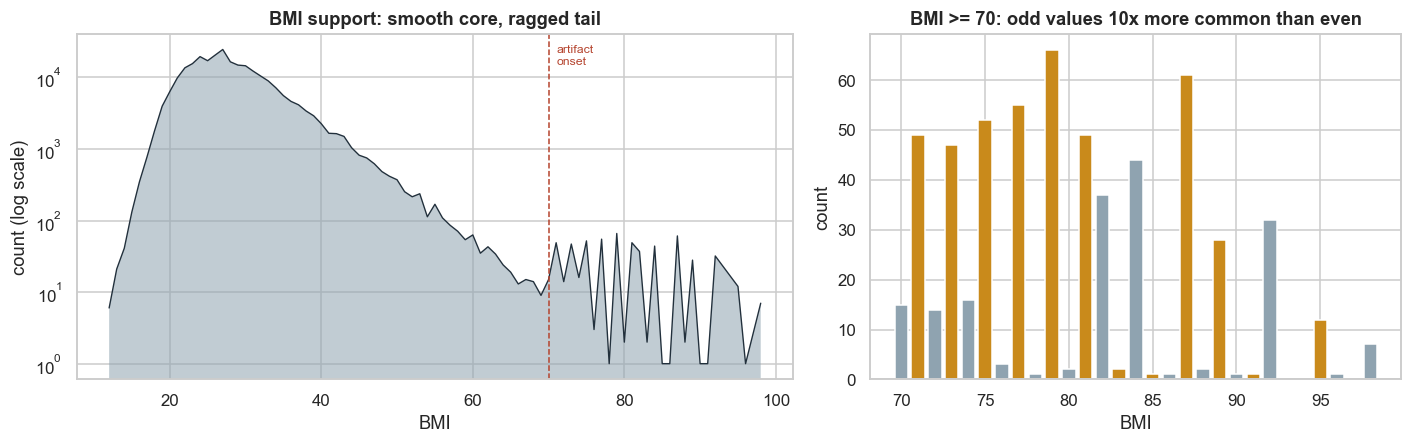

BMI 55-69 (thinning) : 758 rows (0.30% of sample)
BMI >= 70 (artifact) : 599 rows (0.24% of sample)   BMI >= 80 : 281   BMI = 98 : 7
BMI < 16 : 200


In [64]:
vc = raw.BMI.value_counts().sort_index()
tail = vc.loc[70:]
tail_parity = np.where(tail.index % 2 == 1, "odd", "even")
odd_med  = np.median(tail.values[tail_parity == "odd"])
even_med = np.median(tail.values[tail_parity == "even"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
ax.fill_between(vc.index, vc.values, color=PALETTE["neg"], alpha=.55, lw=0)
ax.plot(vc.index, vc.values, color=PALETTE["ink"], lw=.9)
ax.set_yscale("log"); ax.set_xlabel("BMI"); ax.set_ylabel("count (log scale)")
ax.set_title("BMI support: smooth core, ragged tail")
ax.axvline(70, color=PALETTE["pos"], ls="--", lw=1)
ax.text(71, ax.get_ylim()[1] * .5, "artifact\nonset", color=PALETTE["pos"], fontsize=8, va="center")

ax = axes[1]
ax.bar(tail.index, tail.values, width=.8,
       color=[PALETTE["accent"] if p == "odd" else PALETTE["neg"] for p in tail_parity])
ax.set_xlabel("BMI"); ax.set_ylabel("count")
ax.set_title(f"BMI >= 70: odd values {odd_med/even_med:.0f}x more common than even")
plt.tight_layout(); plt.show()

print(f"BMI 55-69 (thinning) : {raw.BMI.between(55, 69).sum():,} rows "
      f"({100*raw.BMI.between(55, 69).mean():.2f}% of sample)")
print(f"BMI >= 70 (artifact) : {(raw.BMI>=70).sum():,} rows "
      f"({100*(raw.BMI>=70).mean():.2f}% of sample)   BMI >= 80 : {(raw.BMI>=80).sum():,}   "
      f"BMI = 98 : {(raw.BMI==98).sum():,}")
print(f"BMI < 16 : {(raw.BMI<16).sum():,}")

The tail has two regimes. From the mid-50s to about 70 it simply thins: every
integer value is still present and the counts fall away smoothly. That is a sparse
tail, not a corrupted one, and those rows are kept as real.

Above 70 the pattern changes. Odd BMI values become far more common than even ones
and carry most of the remaining mass, so the variable is no longer recording a
measurement there and most likely it is being back-calculated from height and weight
that were themselves rounded, though the exact mechanism is unclear. Very few rows
sit above 70, but in a variance-sensitive method they carry leverage far out of
proportion to their number. 

### Recoding BMI

Two derived columns come out of this. `bmi_cat` bins BMI at the standard WHO
cut-points, folding everything at or above 40 into a single "obese III" class,
which handles both the ragged tail and the non-linear risk gradient in one step.
`bmi_winsor` caps the raw number at 70 for places a numeric BMI is still needed,
pulling the digit artifact back to the edge of the believable range without
dropping any rows. The original, uncapped `BMI` column is kept alongside both.

In [65]:
BMI_BINS   = [0, 18.5, 25, 30, 35, 40, 99]
BMI_LABELS = ["underweight", "normal", "overweight", "obese I", "obese II", "obese III"]

raw["bmi_cat"]    = pd.cut(raw.BMI, BMI_BINS, right=False, labels=BMI_LABELS)
raw["bmi_winsor"] = np.minimum(raw.BMI, 70)

summary = raw.groupby("bmi_cat", observed=True).agg(
    n=("BMI", "size"), bmi_min=("BMI", "min"), bmi_max=("BMI", "max"),
    prevalence=(TARGET, "mean"))
summary["share %"]      = (100 * summary.n / len(raw)).round(2)
summary["prevalence %"] = (100 * summary.prevalence).round(2)

display(summary[["n", "share %", "bmi_min", "bmi_max", "prevalence %"]])

print(f"rows winsorised by the BMI 70 cap : {(raw.BMI > 70).sum():,}")
print("bmi_cat and bmi_winsor are now available for the rest of the notebook.")

,n,share %,bmi_min,bmi_max,prevalence %
bmi_cat,,,,,
underweight,3127,1.230,12.000,18.000,6.300
normal,68953,27.180,19.000,24.000,6.700
overweight,93749,36.960,25.000,29.000,13.030
obese I,53451,21.070,30.000,34.000,21.690
obese II,20663,8.150,35.000,39.000,30.570
obese III,13737,5.420,40.000,98.000,36.630


rows winsorised by the BMI 70 cap : 584
bmi_cat and bmi_winsor are now available for the rest of the notebook.


## 4.4 Structural Issues: Zero-Inflation and Near-Constant Columns

Two further problems are not "dirty data" in the usual sense, but will mislead
anyone who summarizes these columns with a mean and standard deviation.

In [66]:
# Zero-inflation in the two 30-day count variables
for v in ["MentHlth", "PhysHlth"]:
    zeros = 100 * (raw[v] == 0).mean()
    at30  = 100 * (raw[v] == 30).mean()
    print(f"{v}: {zeros:.1f}% are exactly 0 | {at30:.1f}% are exactly 30 "
          f"| mean = {raw[v].mean():.2f}, median = {raw[v].median():.0f}")

MentHlth: 69.3% are exactly 0 | 4.8% are exactly 30 | mean = 3.18, median = 0
PhysHlth: 63.1% are exactly 0 | 7.6% are exactly 30 | mean = 4.24, median = 0


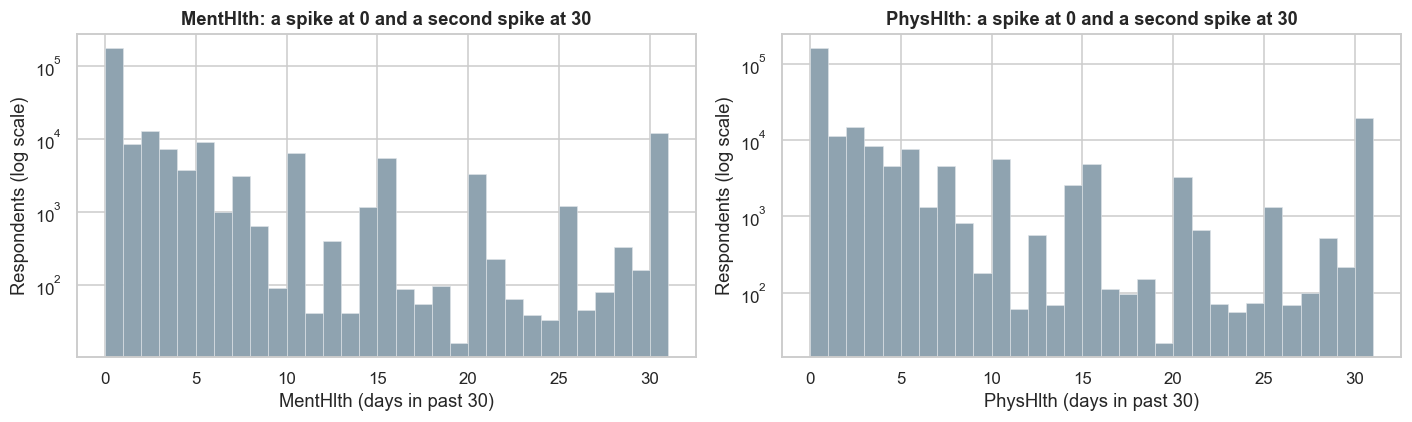

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, v in zip(axes, ["MentHlth", "PhysHlth"]):
    ax.hist(raw[v], bins=range(0, 32), color=PALETTE["neg"], edgecolor=PALETTE["grid"], linewidth=0.4)
    ax.set_yscale("log")
    ax.set_xlabel(f"{v} (days in past 30)")
    ax.set_ylabel("Respondents (log scale)")
    ax.set_title(f"{v}: a spike at 0 and a second spike at 30")
plt.tight_layout()
plt.show()

Both variables are zero-inflated with a secondary spike at 30. Roughly
two-thirds of respondents report zero bad days, and a small but distinct group
reports that every day was bad.

This is not a continuous distribution and should not be summarized as one. The
mean of `MentHlth` sits in a valley between two clusters, describing a respondent
who barely exists. How we deal with it: treat these as categorical bands
(0 days / 1-13 / 14+ / all 30) rather than as continuous counts where that
distinction matters, and test whether the bands separate the classes.

In [68]:
# Near-constant columns carry little information on their own
binary_cols = [c for c in FEATURES if raw[c].nunique() == 2 and c != "Sex"]

balance = pd.DataFrame({
    "pct_1": (100 * raw[binary_cols].mean()).round(1),
}).sort_values("pct_1")
balance["minority_share"] = balance.pct_1.where(balance.pct_1 < 50, 100 - balance.pct_1)
balance["flag"] = np.where(balance.minority_share < 10, "near-constant", "")
balance

,pct_1,minority_share,flag
Stroke,4.100,4.100,near-constant
HvyAlcoholConsump,5.600,5.600,near-constant
NoDocbcCost,8.400,8.400,near-constant
HeartDiseaseorAttack,9.400,9.400,near-constant
DiffWalk,16.800,16.800,
HighChol,42.400,42.400,
HighBP,42.900,42.900,
Smoker,44.300,44.300,
Fruits,63.400,36.600,
PhysActivity,75.700,24.300,


Several variables have a minority class below 10% (`CholCheck`, `AnyHealthcare`,
`Stroke`, `HvyAlcoholConsump`, `NoDocbcCost`, `HeartDiseaseorAttack`). These are not
errors as they are genuinely rare conditions or near-universal behaviors. This means we will keep
all of them. Rare events can still be strongly predictive when they do occur, and
several combine into useful composite features. A low minority share
is a reason to check a variable, not a reason to drop it.

## 4.5 Cleaning Summary

| Issue | Finding | Decision | Rationale |
|---|---|---|---|
| Missing values | Zero, but only because incomplete records were pre-removed | Document the narrowed population | No imputation possible; the bias is in what was already dropped |
| Duplicate rows | ~9% of rows are exact duplicates | **Keep all** (Decision #3) | Removing them inflates the apparent diabetes rate by preferentially deleting healthy profiles, confirmed by both a headline shift and a fuller profile comparison |
| BMI tail | Digit-rounding artifact appears above BMI 70 | **Winsorise at 70 for numeric use; keep the original column** (Decision #2) | The cutoff follows a diagnosed artifact, not an arbitrary percentile |
| Zero-inflation | `MentHlth`, `PhysHlth` both spike at 0 and at 30 | **Band into categories where that distinction matters** | Mean is uninterpretable between two clusters |
| Near-constant cols | Several columns with < 10% minority class | **Keep** | Rare but predictive; useful in composites |
| Label validity | Measures diagnosis, not disease (Decision #7) | **Document; withhold access variables from risk models; model the undiagnosed separately** | Cannot be fixed in the data, only reported and worked around |

No rows were deleted. Two derived columns were added (`bmi_cat`, `bmi_winsor`), and
the target was recoded to `Diabetes_binary` per Decision #1.

# 5. Sample Representativeness — Comparing to the US Population

Section 1 flagged two facts about this file: the BRFSS design weights are absent,
and about 43% of the original respondents were removed by a complete-case filter.
Together they mean the sample's demographic marginals need not match the US adult
population, and wherever they do not, every prevalence figure in this notebook is
shifted away from the population value.

This section measures that gap on the three demographic axes the file carries:
**age**, **household income**, and **educational attainment**. The reference is
the **2015 American Community Survey 1-year** release, pulled from the Census API
(`B01001` for age, `B19001` for household income, `B15003` for education), with
each set of ACS brackets collapsed onto the BRFSS coding.

The BRFSS and ACS figures misalign on three points. BRFSS `Income` is reported by
each adult about their household, whereas the ACS distribution is over households,
so the two do not share exactly the same base. ACS educational attainment is
tabulated for ages 25 and over, against a BRFSS frame of 18 and over. Finally, the
BRFSS income and education non-responses were dropped before this CSV was written,
while the ACS imputes them. ACS margins of error are negligible at national scale
and are not shown.

The API pull lives in `scripts/build_census_reference.py`, outside this notebook.
It fetches the three ACS tables, applies the bracket crosswalks, and writes
`Lab1/cache/census_2015_reference.json`. The next cell hardcodes the figures from
that file, so this section needs no network access and no Census API key to run.

In [69]:
AGE_LAB = ["18-24","25-29","30-34","35-39","40-44","45-49","50-54",
           "55-59","60-64","65-69","70-74","75-79","80+"]
INC_LAB = ["<$10k","$10-15k","$15-20k","$20-25k","$25-35k","$35-50k","$50-75k","$75k+"]
EDU_LAB = ["Never\nattended","Elementary","Some HS","HS grad",
           "Some college /\ntechnical","College grad"]

def wilson(k, n, z=1.96):
    """Wilson score interval for a binomial proportion k/n."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))

In [70]:
# Hardcoded from cache/census_2015_reference.json (2015 ACS 1-year estimates:
# B01001 age, B19001 household income, B15003 education), collapsed onto the
# BRFSS band scheme by scripts/build_census_reference.py. See the prose above
# for how to regenerate this file and why it is embedded rather than read live.
ref = {
    "age": {
        "labels": [
            "18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64",
            "65-69", "70-74", "75-79", "80+"
        ],
        "counts": [
            31341948, 22292402, 21605430, 20497148, 20306982, 20825489,
            22310091, 21590716, 19286425, 16077656, 11509611, 8141322,
            12003891,
        ],
        "base": 247789111,
        "share": [
            0.12648638139712282, 0.08996522046523667, 0.08719281453816588,
            0.08272013212073714, 0.081952681124878, 0.0840452145615067,
            0.09003660778297881, 0.08713343339772506, 0.07783402959946856,
            0.06488443311780556, 0.04644922028070878, 0.03285585055430462,
            0.0484439810593614,
        ],
    },
    "income": {
        "labels": [
            "<10k", "10-15k", "15-20k", "20-25k", "25-35k", "35-50k", "50-75k", ">=75k"
        ],
        "counts": [
            8104547, 5861099, 5903590, 6185673, 11602462, 15642652,
            21068316, 43839911,
        ],
        "base": 118208250,
        "share": [
            0.06856160208784073, 0.049582825225819686, 0.04994228406223762,
            0.052328606505891086, 0.09815272622680735, 0.13233130513310196,
            0.17823050421607628, 0.3708701465422253,
        ],
    },
    "education": {
        "labels": [
            "never attended", "elementary", "some HS", "HS grad", "some college", "college grad"
        ],
        "counts": [
            3208900, 8779139, 15838087, 59662981, 62716503, 66241553,
        ],
        "base": 216447163,
        "share": [
            0.014825327140000445, 0.04056019436022823, 0.07317299418703861,
            0.27564686075372585, 0.2897543314069679, 0.306040292152039,
        ],
    },
}

for dim in ("age", "income", "education"):
    assert abs(sum(ref[dim]["share"]) - 1.0) < 1e-9, dim

print(f"census reference [hardcoded]   US pop 18+ {ref['age']['base']:,}   "
      f"households {ref['income']['base']:,}   US pop 25+ {ref['education']['base']:,}")

census reference [hardcoded]   US pop 18+ 247,789,111   households 118,208,250   US pop 25+ 216,447,163


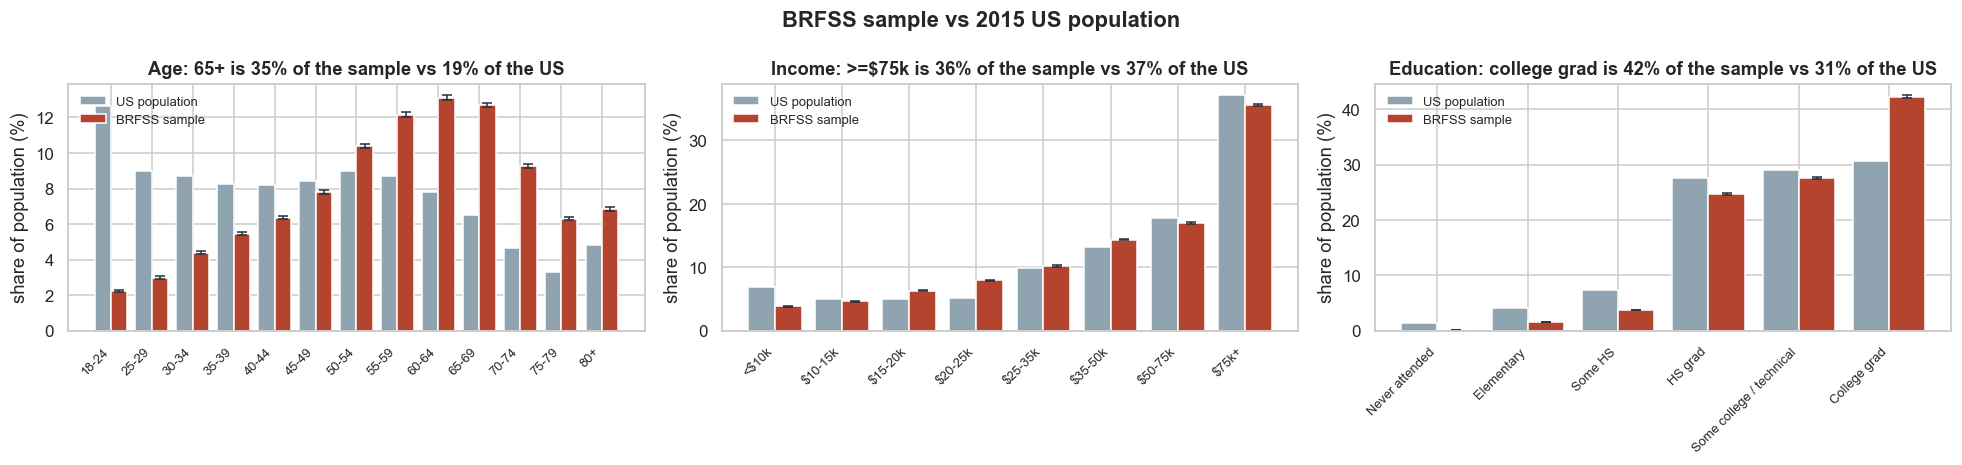

In [71]:
BANDS = {"age": (range(1, 14), AGE_LAB), "income": (range(1, 9), INC_LAB),
         "education": (range(1, 7), EDU_LAB)}
COLS  = {"age": "Age", "income": "Income", "education": "Education"}
HEAD  = {"age": (slice(9, 13), "65+"), "income": (slice(7, 8), ">=$75k"),
         "education": (slice(5, 6), "college grad")}


def _sample_share(dim):
    rng = BANDS[dim][0]
    cnt = raw[COLS[dim]].value_counts().reindex(rng, fill_value=0).to_numpy()
    return cnt, cnt / cnt.sum()


fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
for ax, dim in zip(axes, ("age", "income", "education")):
    labs   = [l.replace("\n", " ") for l in BANDS[dim][1]]
    us     = np.array(ref[dim]["share"])
    cnt, samp = _sample_share(dim)
    lo, hi = map(np.array, zip(*[wilson(int(k), int(cnt.sum())) for k in cnt]))
    x = np.arange(len(labs)); w = .4
    ax.bar(x - w/2, 100*us,   w, color=PALETTE["neg"],  label="US population")
    ax.bar(x + w/2, 100*samp, w, color=PALETTE["pos"], label="BRFSS sample",
           yerr=[100*(samp - lo), 100*(hi - samp)],
           error_kw=dict(ecolor=PALETTE["ink"], lw=1, capsize=3))
    ax.set_xticks(x); ax.set_xticklabels(labs, rotation=45, ha="right", fontsize=8.5)
    ax.set_ylabel("share of population (%)")
    sl, name = HEAD[dim]
    ax.set_title(f"{dim.capitalize()}: {name} is {100*samp[sl].sum():.0f}% of the "
                 f"sample vs {100*us[sl].sum():.0f}% of the US")
    ax.legend(fontsize=8.5, frameon=False)
fig.suptitle("BRFSS sample vs 2015 US population", fontweight="bold")
plt.tight_layout(); plt.show()

In [72]:
rows_, tvd = [], {}
for dim in ("age", "income", "education"):
    labs   = [l.replace("\n", " ") for l in BANDS[dim][1]]
    us     = np.array(ref[dim]["share"])
    cnt, samp = _sample_share(dim)
    lo, hi = zip(*[wilson(int(k), int(cnt.sum())) for k in cnt])
    tvd[dim] = 0.5 * np.abs(samp - us).sum()
    for i, lab in enumerate(labs):
        rows_.append({"dimension": dim, "band": lab,
                      "US %": 100*us[i], "sample %": 100*samp[i],
                      "diff (pts)": 100*(samp[i] - us[i]),
                      "sample 95% CI": f"[{100*lo[i]:.2f}, {100*hi[i]:.2f}]"})

diff_table = pd.DataFrame(rows_)
display(diff_table.round(2))

print("total variation distance from a representative sample (0 = identical, 1 = disjoint):")
for dim, v in tvd.items():
    print(f"  {dim:9s} {v:.3f}")

,dimension,band,US %,sample %,diff (pts),sample 95% CI
0,age,18-24,12.650,2.250,-10.400,"[2.19, 2.31]"
1,age,25-29,9.000,3.000,-6.000,"[2.93, 3.06]"
2,age,30-34,8.720,4.380,-4.330,"[4.31, 4.47]"
3,age,35-39,8.270,5.450,-2.820,"[5.36, 5.54]"
4,age,40-44,8.200,6.370,-1.830,"[6.27, 6.46]"
5,age,45-49,8.400,7.810,-0.590,"[7.71, 7.92]"
6,age,50-54,9.000,10.370,1.370,"[10.25, 10.49]"
7,age,55-59,8.710,12.150,3.440,"[12.03, 12.28]"
8,age,60-64,7.780,13.100,5.320,"[12.97, 13.24]"
9,age,65-69,6.490,12.690,6.200,"[12.56, 12.82]"


total variation distance from a representative sample (0 = identical, 1 = disjoint):
  age       0.260
  income    0.055
  education 0.117


# 6. The Target Variable


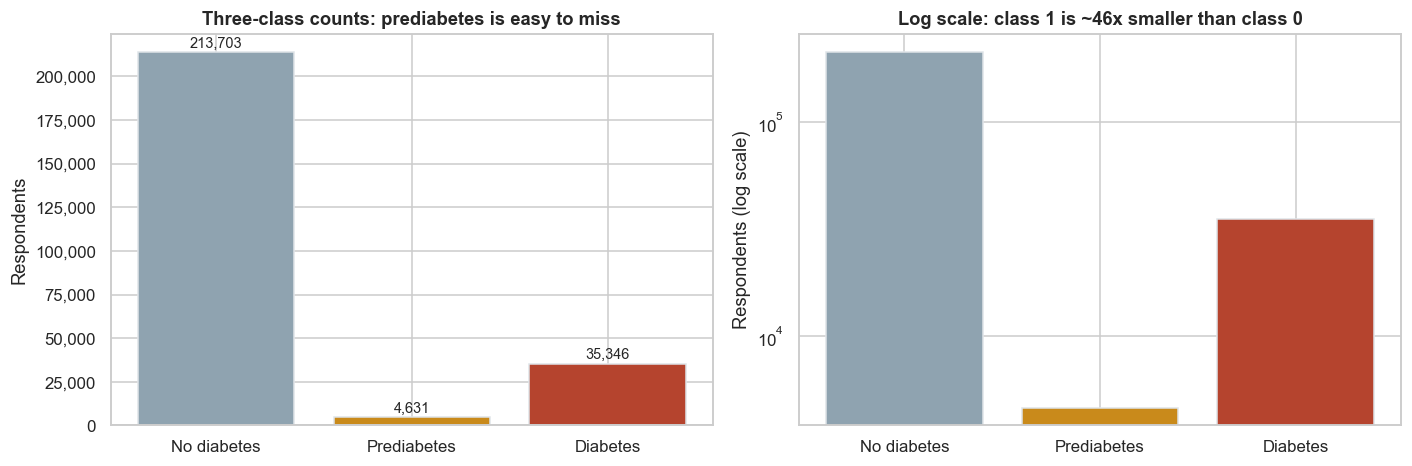

class 1 (prediabetes) is 46x smaller than class 0


In [73]:
counts_012 = raw.Diabetes_012.value_counts().sort_index()
labels_012 = ["No diabetes", "Prediabetes", "Diabetes"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

bars = axes[0].bar(labels_012, counts_012.values, color=PALETTE_012, edgecolor=PALETTE["grid"])
axes[0].set_ylabel("Respondents")
axes[0].set_title("Three-class counts: prediabetes is easy to miss")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for b, v in zip(bars, counts_012.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 3000, f"{v:,}", ha="center", fontsize=9.5)

axes[1].bar(labels_012, counts_012.values, color=PALETTE_012, edgecolor=PALETTE["grid"])
axes[1].set_yscale("log")
axes[1].set_ylabel("Respondents (log scale)")
axes[1].set_title("Log scale: class 1 is ~46x smaller than class 0")

plt.tight_layout()
plt.show()

print(f"class 1 (prediabetes) is {counts_012[0]/counts_012[1]:.0f}x smaller than class 0")

On a linear
scale the prediabetes class is barely readable, and the log-scaled panel confirms
it because roughly 46 times fewer respondents than the no-diabetes class. Beyond size,
the CDC estimates roughly a third of US adults have prediabetes, but only ~1.8% of
this sample is coded as such: that gap is diagnostic access, not biology. Most
people with prediabetes have never been told, so the class is not just rare, it
is unreliably labeled which is a second  reason to
prefer the binary framing.

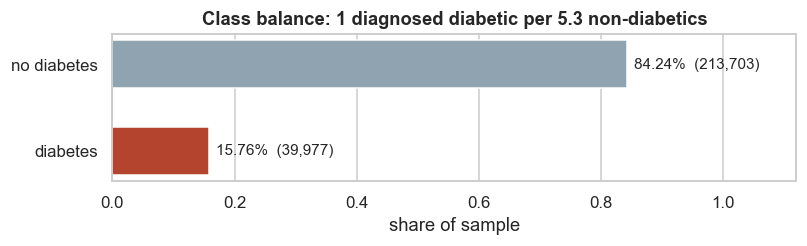

positive class: 39,977 rows (15.76%)
accuracy of a model that always predicts 'no diabetes': 84.24%


In [74]:
prev = raw[TARGET].mean()

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.barh(["diabetes", "no diabetes"], [prev, 1-prev],
        color=[PALETTE["pos"], PALETTE["neg"]], height=.55)
for i, v in enumerate([prev, 1-prev]):
    ax.text(v + .012, i, f"{v*100:.2f}%  ({int(v*len(raw)):,})", va="center", fontsize=10)
ax.set_xlim(0, 1.12); ax.set_xlabel("share of sample")
ax.set_title(f"Class balance: 1 diagnosed diabetic per {(1-prev)/prev:.1f} non-diabetics")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"positive class: {raw[TARGET].sum():,.0f} rows ({100*prev:.2f}%)")
print(f"accuracy of a model that always predicts 'no diabetes': {100*(1-prev):.2f}%")

### Interpretation

Under the binary framing, the positive class (prediabetes or diagnosed diabetes)
is about 15.8% of the sample. The sample skews older than the general population,
so this figure overstates the national rate of *diagnosed* disease, and the
diagnosis-vs-disease gap means it understates the true rate of the underlying
condition. Both biases point the same direction, away from this number being a
population estimate.

Three consequences follow, and both feed directly into Section 15:

1. The ~84% majority sets the accuracy floor. Any model must beat that to be
   worth anything.
2. This is a hard classification problem even before modeling starts because the
   positive class is a small minority of a sample that is itself not
   representative of the population it's drawn from.
3. The gap between this number and the true prevalence is the subject of
   Sections 15.2 and 15.3.

# 7. Distributions of Key Attributes

## 7.1 BMI — diabetic median sits higher, but the groups overlap heavily

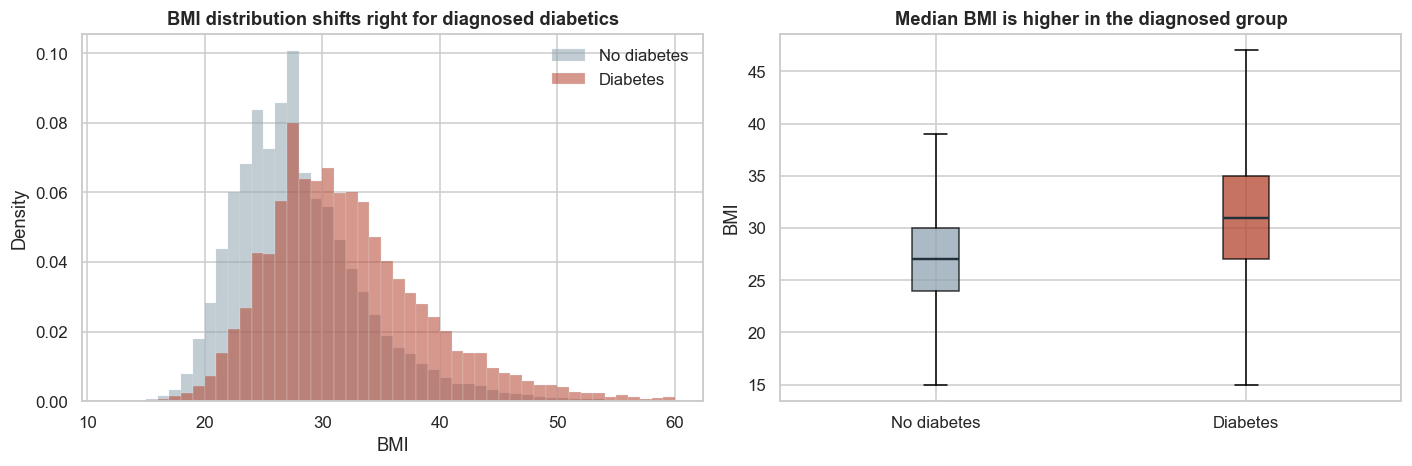

                 median   mean   std
Diabetes_binary                     
0                27.000 27.740 6.260
1                31.000 31.800 7.330


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Overlaid densities let the (very differently-sized) groups be compared directly
for is_dia, lab, col in zip([0, 1], ["No diabetes", "Diabetes"], [PALETTE["neg"], PALETTE["pos"]]):
    subset = raw.loc[raw[TARGET] == is_dia, "BMI"]
    axes[0].hist(subset, bins=range(12, 61), density=True, alpha=0.55,
                 label=lab, color=col, edgecolor=PALETTE["grid"], linewidth=0.3)
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Density")
axes[0].set_title("BMI distribution shifts right for diagnosed diabetics")
axes[0].legend(frameon=False)

box_data = [raw.loc[raw[TARGET] == c, "BMI"] for c in [0, 1]]
bp = axes[1].boxplot(box_data, tick_labels=["No diabetes", "Diabetes"], patch_artist=True,
                      showfliers=False, medianprops=dict(color=PALETTE["ink"], linewidth=1.6))
for patch, col in zip(bp["boxes"], [PALETTE["neg"], PALETTE["pos"]]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
axes[1].set_ylabel("BMI")
axes[1].set_title("Median BMI is higher in the diagnosed group")

plt.tight_layout()
plt.show()

print(raw.groupby(TARGET)["BMI"].agg(["median", "mean", "std"]).round(2).to_string())

BMI is the only true continuous variable in the dataset, so a density
histogram is appropriate; normalizing to density lets two very differently-sized
groups be compared on the same axes (raw counts would make the diabetic group
invisible). The box plot compresses each group to its median and quartiles;
outlier points are suppressed since with 253,680 rows they form an unreadable
smear.

### Interpretation

The diabetic distribution is shifted right at the median. The shift is in the
body of the distribution, not driven by the extreme tail and BMI carries signal
across its normal range, not only among the severely obese. The overlap between
groups is still substantial: plenty of people with a moderate BMI have diabetes and
plenty with a high BMI do not. BMI is a genuine risk factor but nowhere near
deterministic on its own.

## 7.2 General Health

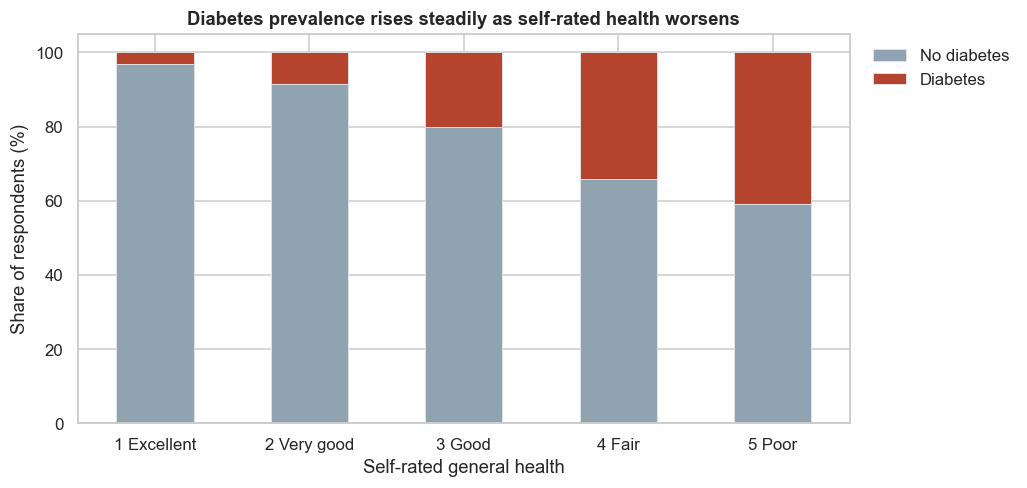

,No diabetes,Diabetes
1 Excellent,96.800,3.200
2 Very good,91.500,8.500
3 Good,79.900,20.100
4 Fair,65.700,34.300
5 Poor,59.200,40.800


In [76]:
gen = pd.crosstab(raw.GenHlth, raw[TARGET], normalize="index") * 100
gen.columns = ["No diabetes", "Diabetes"]
gen.index = ["1 Excellent", "2 Very good", "3 Good", "4 Fair", "5 Poor"]

ax = gen.plot(kind="bar", stacked=True, figsize=(9.5, 4.6),
              color=[PALETTE["neg"], PALETTE["pos"]], edgecolor=PALETTE["grid"], linewidth=0.6)
ax.set_xlabel("Self-rated general health")
ax.set_ylabel("Share of respondents (%)")
ax.set_title("Diabetes prevalence rises steadily as self-rated health worsens")
ax.legend(title="", frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gen.round(1)

### Interpretation

This is the strongest single relationship in the dataset by the Cramér's V ranking. The diabetes rate climbs sharply from those rating their health
excellent to those rating it poor but this variable needs care, because
self-rated health is partly a consequence of having diabetes, not only a
predictor of it. Someone managing diabetes and its complications will rate their
health worse partly because of the diabetes, and it also correlates strongly with
poor physical health days and walking difficulty, so much of what it measures is
captured elsewhere too.

It is an excellent screening signal because someone rating their health poorly
warrants attention but a poor causal one. It cannot support a claim that
improving how someone feels about their health would reduce their diabetes risk.

## 7.3 Age

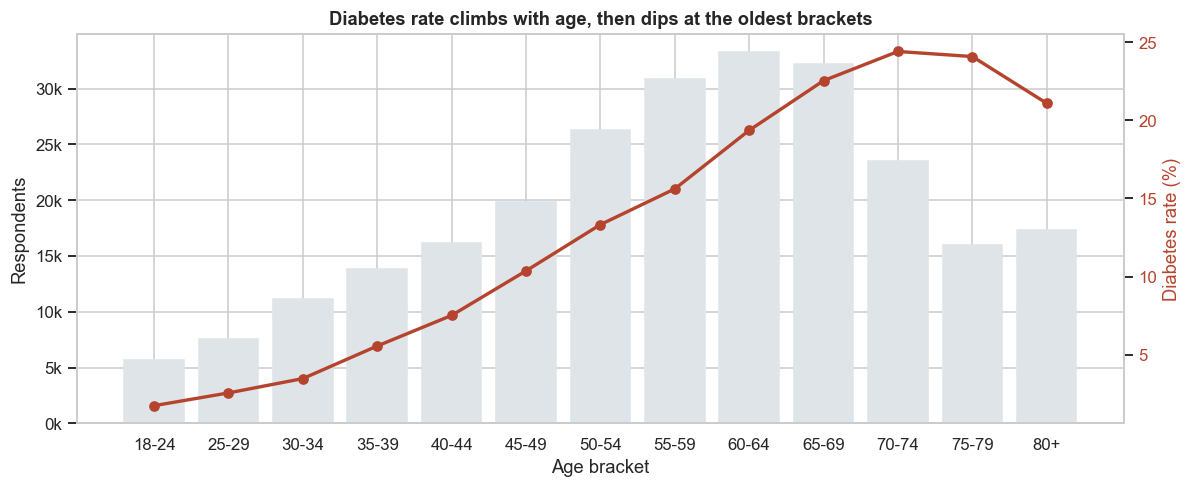

,pct_diabetes,pct_prediabetes,n
18-24,1.700,0.400,5700.000
25-29,2.600,0.700,7598.000
30-34,3.500,0.600,11123.000
35-39,5.600,1.000,13823.000
40-44,7.500,1.000,16157.000
45-49,10.400,1.600,19819.000
50-54,13.300,1.600,26314.000
55-59,15.600,1.800,30832.000
60-64,19.400,2.100,33244.000
65-69,22.500,2.200,32194.000


In [77]:
age_labels = ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54",
              "55-59", "60-64", "65-69", "70-74", "75-79", "80+"]

age_rate = raw.groupby("Age").apply(
    lambda g: pd.Series({
        "pct_diabetes":    100 * (g[TARGET] == 1).mean(),
        "pct_prediabetes": 100 * (g.Diabetes_012 == 1).mean(),
        "n": len(g),
    }), include_groups=False)
age_rate.index = age_labels

fig, ax1 = plt.subplots(figsize=(11, 4.6))
ax1.bar(age_rate.index, age_rate.n, color=PALETTE["grid"], edgecolor=PALETTE["grid"],
        label="Respondents (left axis)")
ax1.set_ylabel("Respondents")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax1.set_xlabel("Age bracket")

ax2 = ax1.twinx()
ax2.plot(age_rate.index, age_rate.pct_diabetes, marker="o", color=PALETTE["pos"],
         linewidth=2.2, label="Diagnosed diabetes rate")
ax2.set_ylabel("Diabetes rate (%)", color=PALETTE["pos"])
ax2.tick_params(axis="y", labelcolor=PALETTE["pos"])
ax2.grid(False)

ax1.set_title("Diabetes rate climbs with age, then dips at the oldest brackets")
plt.tight_layout()
plt.show()

age_rate.round(1)

### Interpretation

The diabetes rate rises steeply and monotonically through the 70-74 bracket, then
falls in the oldest brackets. That final dip is almost certainly not a real
decline in risk:

1. Survivor bias. Diabetes raises mortality, so people who developed it earlier
   are less likely to reach the oldest brackets; the surviving population there is
   selectively healthier.
2. Survey coverage. BRFSS is a telephone survey of non-institutionalized
   adults. The sickest oldest respondents are disproportionately in nursing homes
   and never sampled.

## 7.4 Binary health indicators

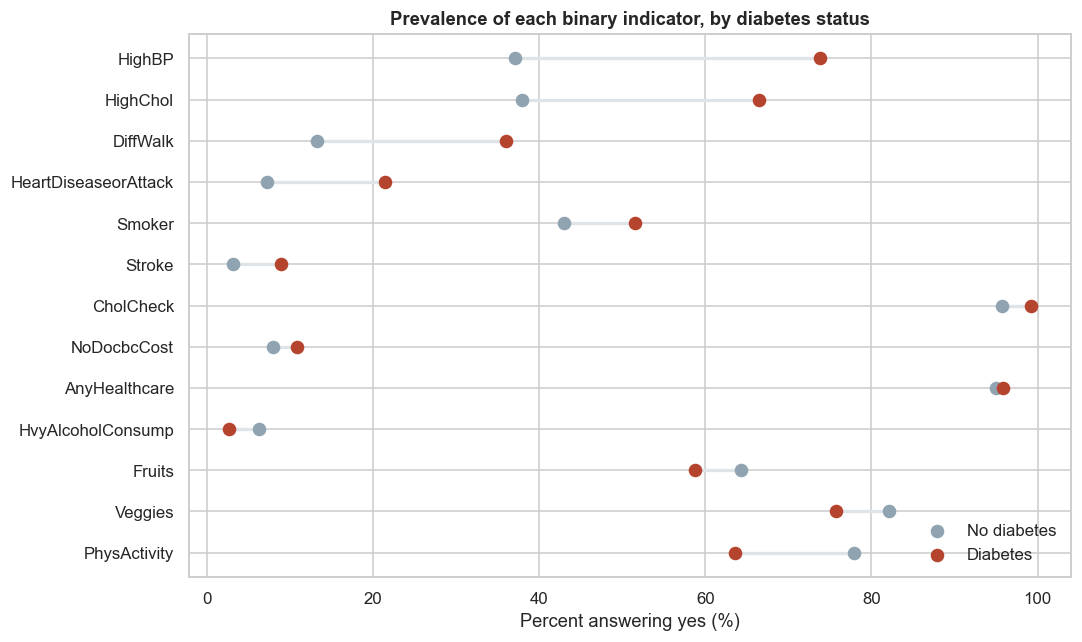

,No diabetes,Diabetes,gap
PhysActivity,77.900,63.600,-14.300
Veggies,82.100,75.800,-6.400
Fruits,64.300,58.700,-5.600
HvyAlcoholConsump,6.200,2.600,-3.600
AnyHealthcare,95.000,95.800,0.800
NoDocbcCost,8.000,10.900,2.900
CholCheck,95.700,99.200,3.500
Stroke,3.200,8.800,5.700
Smoker,43.000,51.500,8.600
HeartDiseaseorAttack,7.200,21.400,14.200


In [78]:
binary_vars = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
               "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
               "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk"]

rates = pd.DataFrame({
    "No diabetes": [100 * raw.loc[raw[TARGET] == 0, v].mean() for v in binary_vars],
    "Diabetes":    [100 * raw.loc[raw[TARGET] == 1, v].mean() for v in binary_vars],
}, index=binary_vars)
rates["gap"] = rates["Diabetes"] - rates["No diabetes"]
rates = rates.sort_values("gap")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rates))
ax.hlines(y, rates["No diabetes"], rates["Diabetes"], color=PALETTE["grid"], linewidth=2.2)
ax.scatter(rates["No diabetes"], y, color=PALETTE["neg"], s=62, label="No diabetes", zorder=3)
ax.scatter(rates["Diabetes"], y, color=PALETTE["pos"], s=62, label="Diabetes", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(rates.index)
ax.set_xlabel("Percent answering yes (%)")
ax.set_title("Prevalence of each binary indicator, by diabetes status")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

rates.round(1)

### Interpretation

`HighBP` and `HighChol` show the widest gaps of the binary indicators. `CholCheck` and `AnyHealthcare` are, by contrast, higher
among diagnosed diabetics through reverse causation. Someone with
diabetes is screened and covered because of the diagnosis process, not the other
way around.

In [79]:
# How two of the strongest risk factors combine
combo = (raw.assign(is_dia=raw[TARGET])
         .groupby(["HighBP", "HighChol"])
         .agg(rate=("is_dia", lambda s: 100 * s.mean()), n=("is_dia", "size")))
combo.index = pd.MultiIndex.from_tuples(
    [("No high BP", "No high chol"), ("No high BP", "High chol"),
     ("High BP", "No high chol"), ("High BP", "High chol")])
combo.round(1)

rate       n
No high BP No high chol  5.000  101920
           High chol    12.400   42931
High BP    No high chol 18.800   44169
           High chol    32.800   64660

### Interpretation

Someone with
neither condition has a low diabetes rate, and someone with both has a
much higher one which is well beyond what either condition shows on its own. Having just
one lands in between. High blood pressure is clearly the stronger of the two
individually. These two are not redundant with each other; we keep both, and their
interaction may add signal a purely additive model would miss.

## 7.5 Income and Education 

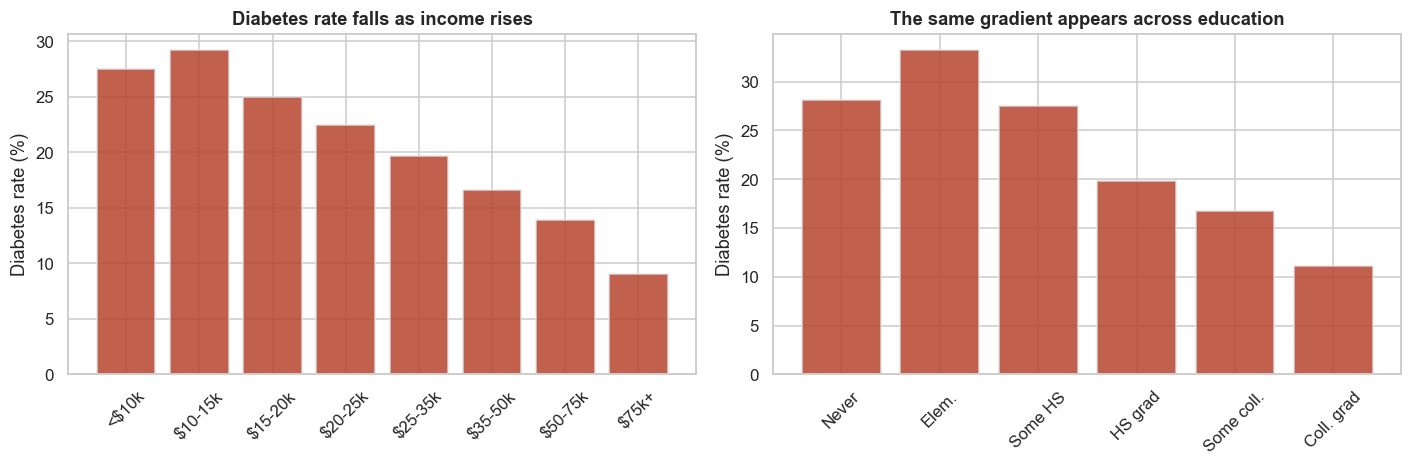

Income gradient: 27.5% (lowest) -> 9.1% (highest)
Education gradient: 28.2% (lowest) -> 11.1% (highest)


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

inc_labels = ["<$10k", "$10-15k", "$15-20k", "$20-25k", "$25-35k", "$35-50k", "$50-75k", "$75k+"]
inc = raw.groupby("Income").apply(
    lambda g: 100 * (g[TARGET] == 1).mean(), include_groups=False)
axes[0].bar(inc_labels, inc.values, color=PALETTE["pos"], alpha=0.85, edgecolor=PALETTE["grid"])
axes[0].set_ylabel("Diabetes rate (%)")
axes[0].set_title("Diabetes rate falls as income rises")
axes[0].tick_params(axis="x", rotation=45)

edu_labels = ["Never", "Elem.", "Some HS", "HS grad", "Some coll.", "Coll. grad"]
edu = raw.groupby("Education").apply(
    lambda g: 100 * (g[TARGET] == 1).mean(), include_groups=False)
axes[1].bar(edu_labels, edu.values, color=PALETTE["pos"], alpha=0.85, edgecolor=PALETTE["grid"])
axes[1].set_ylabel("Diabetes rate (%)")
axes[1].set_title("The same gradient appears across education")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Income gradient:", f"{inc.iloc[0]:.1f}% (lowest) -> {inc.iloc[-1]:.1f}% (highest)")
print("Education gradient:", f"{edu.iloc[0]:.1f}% (lowest) -> {edu.iloc[-1]:.1f}% (highest)")

### Interpretation

The gradient is steep but not perfectly monotonic as it tends to peak in the
second-lowest bracket rather than the very lowest, before falling steadily toward
the top bracket. Income and education correlate with each other too, so they are
substantially measuring the same underlying construct (socioeconomic position); a
model including both gets less additional information from the second than their
individual associations suggest.

The mechanism is not that low income causes diabetes directly, but that it runs
through food environment, time and facilities for physical activity, chronic
stress, and healthcare access. That last one cuts both ways: lower-income
respondents have less access to screening, so their true diabetes rate is probably
understated relative to higher-income respondents. The real
gradient is likely steeper than this chart shows.

## 7.6 Age and BMI: joint structure

Age and BMI are the two strongest continuous risk factors in the data. Sections 7.1
and 7.3 took each one separately. Crossing them answers two further questions: how
much separation the pair achieves together, and whether they combine additively or
interact.

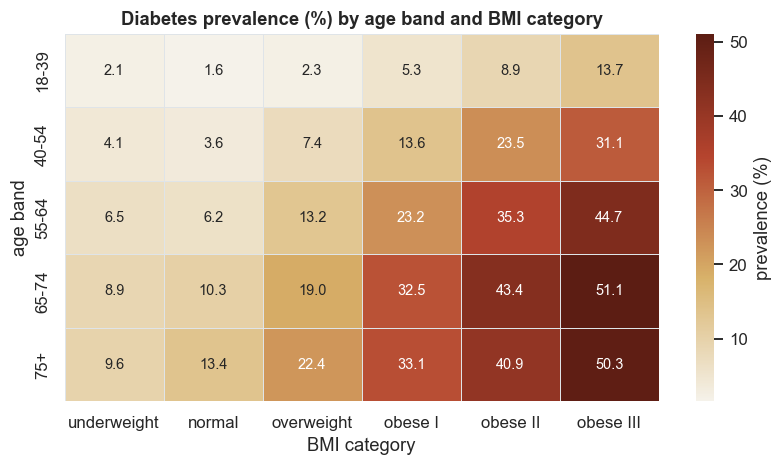

lowest cell  : 1.6%
highest cell : 51.1%   (33x span)

cell counts:


bmi_cat,underweight,normal,overweight,obese I,obese II,obese III
Age,,,,,,
18-39,606,12887,12562,6946,2947,2296
40-54,587,15853,22236,13597,5648,4369
55-64,676,15595,23717,14422,5759,3907
65-74,631,13655,21592,12639,4677,2533
75+,627,10963,13642,5847,1632,632


In [81]:
AGE_GRP = pd.cut(raw.Age, [0, 4, 7, 9, 11, 13],
                 labels=["18-39", "40-54", "55-64", "65-74", "75+"])
BMI_GRP = raw.bmi_cat.cat.remove_unused_categories()

ab_surface = pd.crosstab(AGE_GRP, BMI_GRP, values=raw[TARGET], aggfunc="mean") * 100
ab_counts  = pd.crosstab(AGE_GRP, BMI_GRP)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
sns.heatmap(ab_surface, annot=True, fmt=".1f", cmap=SEQ, ax=ax, linewidths=.6,
            linecolor=PALETTE["grid"], cbar_kws={"label": "prevalence (%)"},
            annot_kws={"fontsize": 9.5})
ax.set_title("Diabetes prevalence (%) by age band and BMI category")
ax.set_xlabel("BMI category"); ax.set_ylabel("age band")
plt.tight_layout(); plt.show()

print(f"lowest cell  : {ab_surface.min().min():.1f}%")
print(f"highest cell : {ab_surface.max().max():.1f}%   "
      f"({ab_surface.max().max() / ab_surface.min().min():.0f}x span)")
print("\ncell counts:")
display(ab_counts)

The grid separates respondents far better than either variable alone: prevalence
runs from 1.6% among 18-39s of normal weight to 51.1% among 65-74s carrying an
obese III BMI, a 33-fold span. Neither variable on its own comes close to that.

The underweight column is the one exception to the otherwise smooth pattern. It is
small (about 3,100 people), and in the age bands up to 64 its prevalence sits
slightly *above* that of normal-weight respondents, which is the signature of
reverse causation rather than risk: illness that causes weight loss. The
comparisons below therefore use normal weight, not underweight, as the reference
group.

Whether the pattern amounts to an **interaction** is a separate question, and the
answer depends on the scale. On the percentage scale the curves fan out. But a
logistic model works in log-odds, and effects that are purely multiplicative
always fan out when read as percentage points, so the fan on its own is not
evidence of anything.

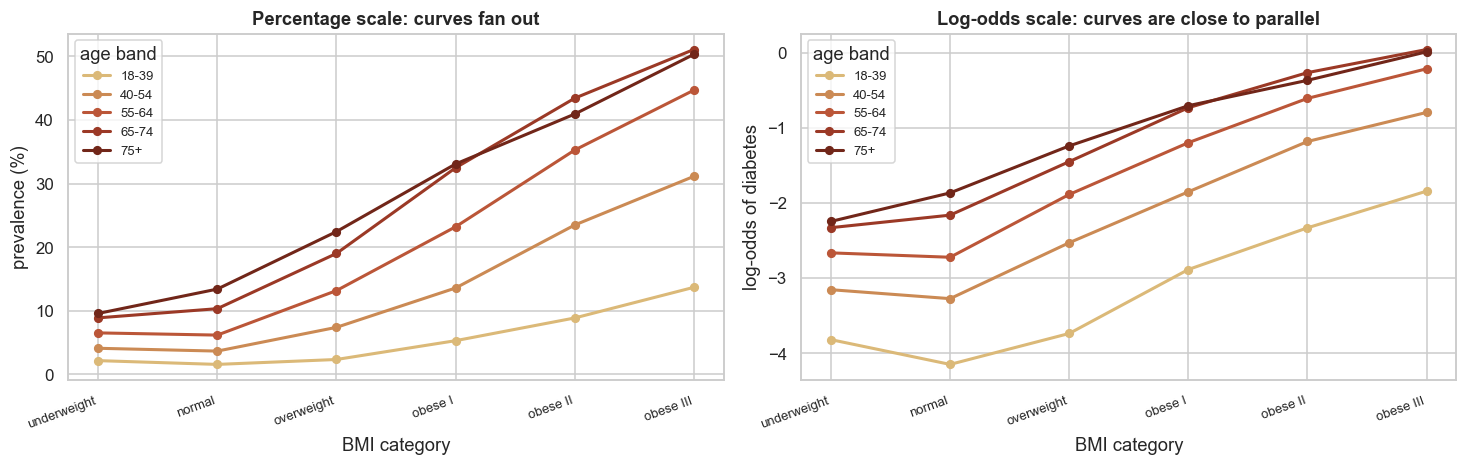

,log-odds at normal BMI,log-odds at obese III,obese III effect (log-odds),obese III effect (odds ratio)
Age,,,,
18-39,-4.150,-1.840,2.310,10.000
40-54,-3.270,-0.790,2.480,11.900
55-64,-2.720,-0.210,2.510,12.300
65-74,-2.160,0.040,2.210,9.100
75+,-1.870,0.010,1.880,6.500


Obese III effect spans 1.88 to 2.51 log-odds (odds ratios 6.5 to 12.3).


In [82]:
ab_L = np.log((ab_surface / 100) / (1 - ab_surface / 100))
band_colors = seq_colors(len(ab_surface.index))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

for ax, frame, ylab, title in [
        (axes[0], ab_surface, "prevalence (%)", "Percentage scale: curves fan out"),
        (axes[1], ab_L, "log-odds of diabetes", "Log-odds scale: curves are close to parallel")]:
    for i, a in enumerate(frame.index):
        ax.plot(range(frame.shape[1]), frame.loc[a], "-o", ms=5, lw=2,
                label=a, color=band_colors[i])
    ax.set_xticks(range(frame.shape[1]))
    ax.set_xticklabels(frame.columns, rotation=20, ha="right", fontsize=8.6)
    ax.set_xlabel("BMI category"); ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend(title="age band", fontsize=8.6)

plt.tight_layout(); plt.show()

ab_gap = ab_L["obese III"] - ab_L["normal"]
display(pd.DataFrame({
    "log-odds at normal BMI":        ab_L["normal"].round(2),
    "log-odds at obese III":         ab_L["obese III"].round(2),
    "obese III effect (log-odds)":   ab_gap.round(2),
    "obese III effect (odds ratio)": np.exp(ab_gap).round(1),
}))

print(f"Obese III effect spans {ab_gap.min():.2f} to {ab_gap.max():.2f} log-odds "
      f"(odds ratios {np.exp(ab_gap).min():.1f} to {np.exp(ab_gap).max():.1f}).")

On the log-odds scale the curves are close to parallel. The BMI effect from normal
weight to obese III is 2.31, 2.48, 2.51 and 2.21 log-odds across the first four
age bands, which is essentially constant; only the oldest band, 75+, is clearly
shallower at 1.88. Read as odds ratios, an obese III BMI multiplies the odds of
diabetes by roughly 9 to 12 at every age below 75, and by about 6.5 above it.

That attenuation in the oldest band is the same survivor-bias story as the age
curve in Section 7.3, seen from the other direction.

In [83]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

X_ab = pd.DataFrame({
    "age": (raw.Age - raw.Age.mean()) / raw.Age.std(),
    "bmi": (raw.bmi_winsor - raw.bmi_winsor.mean()) / raw.bmi_winsor.std(),
})
y_ab = raw[TARGET]

m_add = sm.Logit(y_ab, sm.add_constant(X_ab)).fit(disp=0)
X_ab_int = X_ab.assign(age_x_bmi=X_ab.age * X_ab.bmi)
m_int = sm.Logit(y_ab, sm.add_constant(X_ab_int)).fit(disp=0)

lr_stat = 2 * (m_int.llf - m_add.llf)
lr_p    = stats.chi2.sf(lr_stat, 1)
auc_add = roc_auc_score(y_ab, m_add.predict(sm.add_constant(X_ab)))
auc_int = roc_auc_score(y_ab, m_int.predict(sm.add_constant(X_ab_int)))

display(pd.DataFrame({
    "additive (age + bmi)":       [m_add.prsquared, auc_add, np.nan],
    "with age x bmi interaction": [m_int.prsquared, auc_int,
                                   np.exp(m_int.params["age_x_bmi"])],
}, index=["McFadden pseudo-R2", "ROC-AUC", "interaction odds ratio"]).round(5))

print(f"likelihood-ratio test : chi2 = {lr_stat:.1f} on 1 df, p = {lr_p:.2e}")
print(f"pseudo-R2 gain        : {m_int.prsquared - m_add.prsquared:+.5f}")
print(f"AUC gain              : {auc_int - auc_add:+.5f}")

,additive (age + bmi),with age x bmi interaction
McFadden pseudo-R2,0.107,0.108
ROC-AUC,0.742,0.744
interaction odds ratio,NaN,1.106


likelihood-ratio test : chi2 = 309.1 on 1 df, p = 3.40e-69
pseudo-R2 gain        : +0.00140
AUC gain              : +0.00227


The formal test agrees. Adding an `age x bmi` product term to a logistic model is
detectable, with a chi-square of 309 on 1 degree of freedom, but the effect is
negligible in size: pseudo-R2 rises by 0.0014, AUC by 0.0023, and the interaction
odds ratio is 1.11. At 253,680 rows, statistical detectability again says almost
nothing about practical relevance.

> **Takeaway.** Age and BMI combine close to **multiplicatively**, so an additive
> logistic model in log-odds already captures their joint behaviour and an explicit
> interaction term is not needed. Section 11 returns to this when weighing
> engineered features. The grid is still valuable for risk stratification, because
> multiplying two moderate effects is exactly what produces the 33-fold spread
> above.

# 8. Relationships Between Attributes

,feature,n_categories,chi2,p_value,cramers_v
0,GenHlth,5,23790.979,< 1e-300,0.306
1,HighBP,2,18537.574,< 1e-300,0.270
2,bmi_cat,6,14343.575,< 1e-300,0.238
3,DiffWalk,2,12518.188,< 1e-300,0.222
4,HighChol,2,11217.004,< 1e-300,0.210
5,Age,13,9539.412,< 1e-300,0.194
6,PhysHlth,31,8477.390,< 1e-300,0.183
7,HeartDiseaseorAttack,2,7939.891,< 1e-300,0.177
8,Income,8,7778.993,< 1e-300,0.175
9,Education,6,4541.124,< 1e-300,0.134


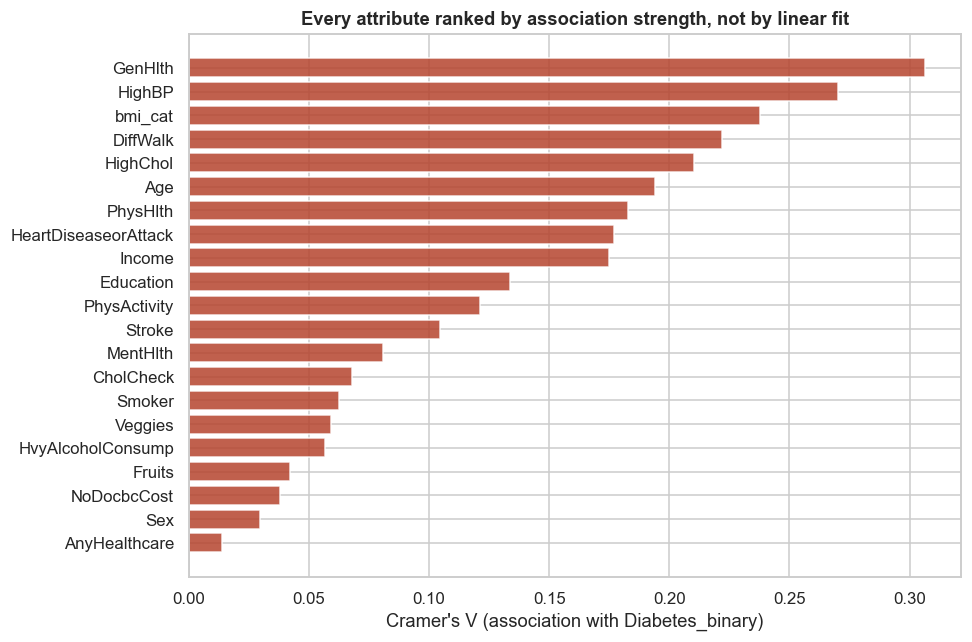

largest Cramer's V : 0.306  (feature: GenHlth)


In [84]:
# Cramer's V / chi-square for every feature against the binary target.
# bmi_cat stands in for BMI (a continuous variable would blow up the contingency
# table); MentHlth/PhysHlth are used as reported (31 levels each).
CORR_FEATURES = [c for c in FEATURES if c not in ("BMI", "bmi_winsor")] + ["bmi_cat"]

rows_ = []
for col in CORR_FEATURES:
    ct = pd.crosstab(raw[col], raw[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    rows_.append({
        "feature": col,
        "n_categories": raw[col].nunique(),
        "chi2": chi2,
        "p_value": p,
        "cramers_v": np.sqrt(chi2 / len(raw)),
    })

sig = pd.DataFrame(rows_).sort_values("cramers_v", ascending=False).reset_index(drop=True)
sig["p_value"] = sig.p_value.apply(lambda v: "< 1e-300" if v == 0 else f"{v:.2e}")

display(sig.round(4))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sig.feature[::-1], sig.cramers_v[::-1], color=PALETTE["pos"], alpha=0.85)
ax.set_xlabel("Cramer's V (association with Diabetes_binary)")
ax.set_title("Every attribute ranked by association strength, not by linear fit")
plt.tight_layout()
plt.show()

print(f"largest Cramer's V : {sig.cramers_v.max():.3f}  (feature: {sig.feature.iloc[0]})")

### Interpretation

No single variable dominates: even the top-ranked feature is a small-to-moderate
effect by conventional standards, and diabetes risk in this data is built from many
moderate signals rather than one strong predictor. That argues for methods that
combine weak signals well and against
expecting a simple rule to work.

A caution on p-values here: with 253,680 rows, even a trivially small effect
reaches significance. The Cramér's V ranking, not the p-value column, is what
should drive feature selection because every one of these associations would reach
significance at a small fraction of this sample size.

In [85]:
# Redundancy among predictors, not just with the target (Harvey's informal
# cross-check on the same idea Section 9's VIF formalizes)
num_feats = [c for c in FEATURES if c not in ("BMI", "bmi_winsor")]
pred_corr = raw[num_feats + ["bmi_winsor"]].apply(pd.to_numeric).corr().abs()
pairs = (pred_corr.where(np.triu(np.ones(pred_corr.shape, dtype=bool), k=1))
         .stack().sort_values(ascending=False).head(8))

print("Most strongly correlated predictor pairs (Pearson, as an intuitive cross-check only):")
for (a, b), v in pairs.items():
    print(f"  {a:<22} ~ {b:<22} r = {v:.2f}")

Most strongly correlated predictor pairs (Pearson, as an intuitive cross-check only):
  GenHlth                ~ PhysHlth               r = 0.52
  PhysHlth               ~ DiffWalk               r = 0.48
  GenHlth                ~ DiffWalk               r = 0.46
  Education              ~ Income                 r = 0.45
  GenHlth                ~ Income                 r = 0.37
  MentHlth               ~ PhysHlth               r = 0.35
  HighBP                 ~ Age                    r = 0.34
  DiffWalk               ~ Income                 r = 0.32


`GenHlth`, `PhysHlth`, and `DiffWalk` form a cluster, all measuring current
physical functioning, and `Education`-`Income` form another, both measuring
socioeconomic position. 

# 9. Multicollinearity

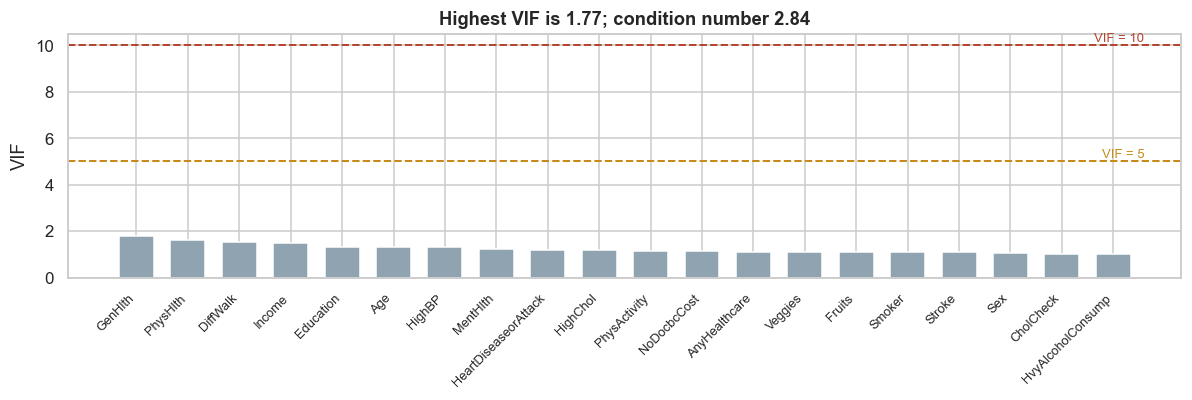

,GenHlth,PhysHlth,DiffWalk,Income,Education,Age,HighBP,MentHlth,HeartDiseaseorAttack,HighChol,PhysActivity,NoDocbcCost,AnyHealthcare,Veggies,Fruits,Smoker,Stroke,Sex,CholCheck,HvyAlcoholConsump
VIF,1.770,1.620,1.520,1.500,1.330,1.320,1.290,1.240,1.170,1.170,1.150,1.140,1.110,1.110,1.110,1.090,1.080,1.070,1.030,1.020


In [86]:
from sklearn.linear_model import LinearRegression

# VIF implemented directly (statsmodels is unavailable in this environment):
# VIF_i = 1 / (1 - R_i^2), where R_i^2 comes from regressing standardized
# feature i on all the other standardized features. This is the same quantity
# statsmodels.stats.outliers_influence.variance_inflation_factor computes.
VIF_FEATURES = [c for c in FEATURES if c not in ("BMI",)]  # use bmi_winsor instead of raw BMI

Xd = raw[VIF_FEATURES].apply(pd.to_numeric)
Xs = (Xd - Xd.mean()) / Xd.std()

vif_vals = {}
for col in Xs.columns:
    y_ = Xs[col].values
    X_ = Xs.drop(columns=[col]).values
    r2 = LinearRegression().fit(X_, y_).score(X_, y_)
    vif_vals[col] = 1.0 / (1.0 - r2) if r2 < 1.0 else np.inf

vif = pd.Series(vif_vals).sort_values(ascending=False)
sv = np.linalg.svd(Xs.values / np.sqrt(len(Xs)), compute_uv=False)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(range(len(vif)), vif.values, color=PALETTE["neg"], width=.68)
ax.axhline(5,  color=PALETTE["accent"], ls="--", lw=1.3)
ax.axhline(10, color=PALETTE["pos"], ls="--", lw=1.3)
ax.text(len(vif)-.4, 5.15,  "VIF = 5",  ha="right", fontsize=8.6, color=PALETTE["accent"])
ax.text(len(vif)-.4, 10.15, "VIF = 10", ha="right", fontsize=8.6, color=PALETTE["pos"])
ax.set_xticks(range(len(vif)))
ax.set_xticklabels(vif.index, rotation=45, ha="right", fontsize=8.4)
ax.set_ylabel("VIF")
ax.set_title(f"Highest VIF is {vif.max():.2f}; condition number {sv.max()/sv.min():.2f}")
plt.tight_layout(); plt.show()

display(vif.round(2).to_frame("VIF").T)


# 10. Group-Wise Comparison

In [87]:
profile = raw.groupby("Diabetes_012").agg(
    n=("BMI", "size"),
    bmi_median=("BMI", "median"),
    bmi_mean=("BMI", "mean"),
    pct_highbp=("HighBP", lambda s: 100 * s.mean()),
    pct_highchol=("HighChol", lambda s: 100 * s.mean()),
    genhlth_mean=("GenHlth", "mean"),
    age_median=("Age", "median"),
    physhlth_mean=("PhysHlth", "mean"),
    pct_diffwalk=("DiffWalk", lambda s: 100 * s.mean()),
    income_median=("Income", "median"),
).round(2)
profile.index = ["No diabetes", "Prediabetes", "Diabetes"]
profile.T

,No diabetes,Prediabetes,Diabetes
n,213703.000,4631.000,35346.000
bmi_median,27.000,30.000,31.000
bmi_mean,27.740,30.720,31.940
pct_highbp,37.110,62.900,75.270
pct_highchol,37.920,62.080,67.010
genhlth_mean,2.370,2.980,3.290
age_median,8.000,9.000,10.000
physhlth_mean,3.580,6.350,7.950
pct_diffwalk,13.230,27.750,37.120
income_median,7.000,6.000,6.000


### Interpretation

Prediabetes sits consistently between the
other two classes on nearly every measure: BMI, blood pressure, cholesterol,
general health, walking difficulty. It is also why prediabetes would be hard to
classify as its own class because it is an intermediate zone, and with
only ~4,631 examples and unreliable labeling, a model has very little
to latch onto that isn't already captured by the other two classes. 

Note that `age_median` and `income_median` are bracket indices, not literal years
or dollars.

# 11. Proposed Feature Engineering Variables

We construct several candidate features and test whether they actually separate
the classes. 

In [88]:
d = raw.copy()

# 1. Clinical BMI categories rather than a raw number (superseded for general use
#    by bmi_cat from Section 4.3, reproduced here for side-by-side comparison)
d["BMI_category"] = d["bmi_cat"]

# 2. Banded poor-health days (handles the zero-inflation from Section 4.4)
def band_days(s):
    return pd.cut(s, bins=[-0.1, 0.5, 13.5, 29.5, 30.1],
                  labels=["0 days", "1-13", "14-29", "all 30"])

d["MentHlth_band"] = band_days(d.MentHlth)
d["PhysHlth_band"] = band_days(d.PhysHlth)

# 3. Count of cardiovascular comorbidities
d["CardioRisk"] = d[["HighBP", "HighChol", "HeartDiseaseorAttack", "Stroke"]].sum(axis=1)

# 4. Healthy-lifestyle score (kept deliberately, see the negative result below)
d["LifestyleScore"] = (d.PhysActivity + d.Fruits + d.Veggies
                        + (1 - d.Smoker) + (1 - d.HvyAlcoholConsump))

print(d[["BMI_category", "MentHlth_band", "CardioRisk", "LifestyleScore"]].head())

  BMI_category MentHlth_band  CardioRisk  LifestyleScore
0    obese III         14-29       2.000           2.000
1   overweight        0 days       0.000           2.000
2   overweight        all 30       2.000           3.000
3   overweight        0 days       1.000           5.000
4       normal          1-13       2.000           5.000


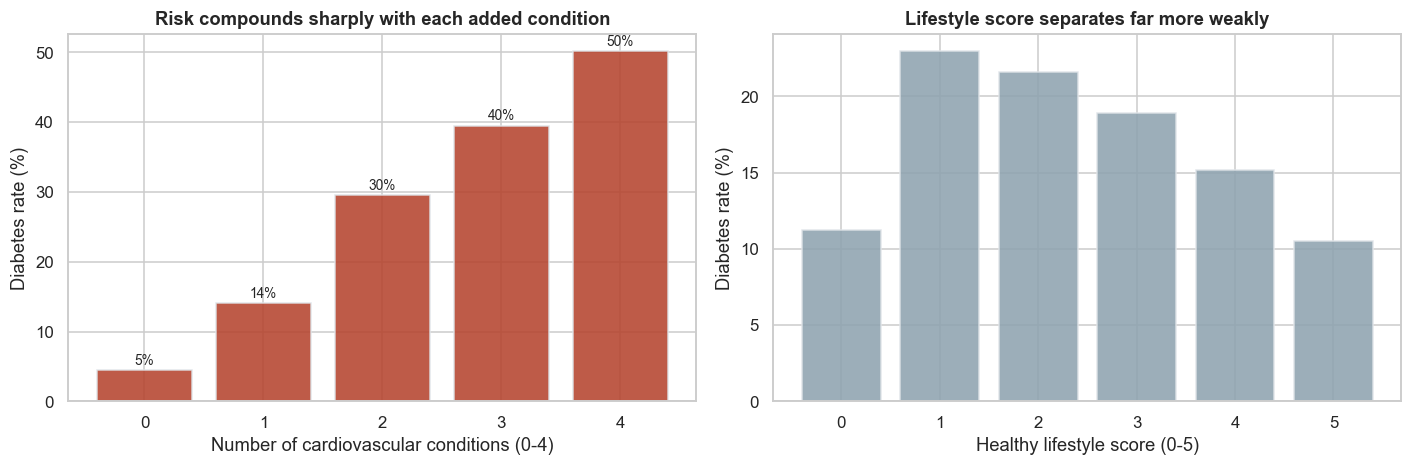

CardioRisk : {0.0: 4.5, 1.0: 14.1, 2.0: 29.6, 3.0: 39.5, 4.0: 50.1}
Lifestyle  : {0.0: 11.2, 1.0: 22.9, 2.0: 21.6, 3.0: 18.9, 4.0: 15.1, 5.0: 10.5}


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

cardio = d.groupby("CardioRisk").apply(
    lambda g: pd.Series({"rate": 100*g[TARGET].mean(), "n": len(g)}),
    include_groups=False)
axes[0].bar(cardio.index.astype(int).astype(str), cardio.rate,
            color=PALETTE["pos"], alpha=0.88, edgecolor=PALETTE["grid"])
axes[0].set_xlabel("Number of cardiovascular conditions (0-4)")
axes[0].set_ylabel("Diabetes rate (%)")
axes[0].set_title("Risk compounds sharply with each added condition")
for i, (r, n) in enumerate(zip(cardio.rate, cardio.n)):
    axes[0].text(i, r + 0.8, f"{r:.0f}%", ha="center", fontsize=9)

life = d.groupby("LifestyleScore").apply(
    lambda g: pd.Series({"rate": 100*g[TARGET].mean(), "n": len(g)}),
    include_groups=False)
axes[1].bar(life.index.astype(int).astype(str), life.rate,
            color=PALETTE["neg"], alpha=0.88, edgecolor=PALETTE["grid"])
axes[1].set_xlabel("Healthy lifestyle score (0-5)")
axes[1].set_ylabel("Diabetes rate (%)")
axes[1].set_title("Lifestyle score separates far more weakly")

plt.tight_layout()
plt.show()

print("CardioRisk :", cardio.rate.round(1).to_dict())
print("Lifestyle  :", life.rate.round(1).to_dict())

### Which engineered features are worth keeping

`CardioRisk` works well. The diabetes rate climbs sharply from zero conditions
to all four forming a cleaner, steeper gradient than any of its four components alone.
It also compresses four sparse binary columns into one ordinal variable, handling
the near-constant-column issue.

`LifestyleScore` works poorly. The gradient is shallow and not fully monotonic. Its components
are weak on their own (fruit and vegetable consumption both show only a very small
association with the target individually). Summing weak, crudely-measured signals
does not manufacture a strong one, and weighting each component equally is hard to
defend because quitting smoking and eating fruit daily are not comparable interventions.

### Other features we could build

Feasible from this data:

- `BMI x Age` interaction. Section 7.6 tests this one directly: the interaction is
  statistically detectable but adds ~0.001 to pseudo-R2 and ~0.002 to AUC, so it is
  not worth carrying as an engineered feature.
- `HealthcareAccess` composite from `AnyHealthcare`, `NoDocbcCost`, and
  `CholCheck`, used as a control to adjust for diagnosis likelihood rather than
  as a predictor of disease.
- `PoorHealthDays` combining `MentHlth` and `PhysHlth` into a single banded
  burden measure.

Would require external data:

- State-level food-environment or deprivation indices, joined on the state
  field, which is present in the raw BRFSS but stripped from this extract.

# 12. Dimensionality Reduction

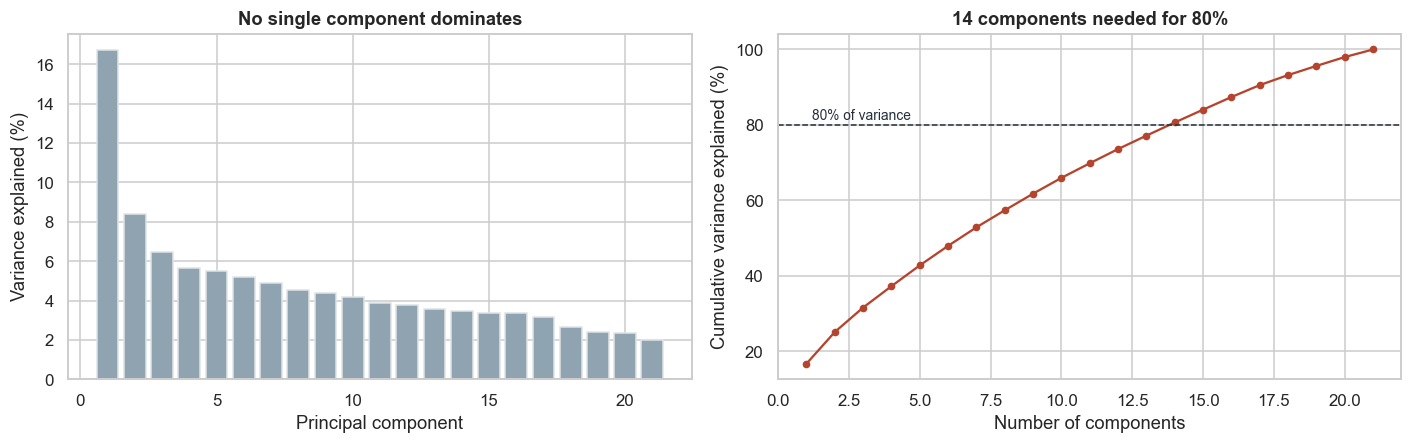

PC1 explains 16.7% of variance
PC1 + PC2: 25.1%
Components needed for 80%: 14


In [90]:
features_pca = [c for c in raw.columns
                if c not in ("Diabetes_012", TARGET, "bmi_cat", "bmi_winsor")]

X = StandardScaler().fit_transform(raw[features_pca].apply(pd.to_numeric))
pca_full = PCA().fit(X)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(range(1, len(evr)+1), 100*evr, color=PALETTE["neg"], edgecolor=PALETTE["grid"])
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("No single component dominates")

axes[1].plot(range(1, len(cum)+1), 100*cum, marker="o", color=PALETTE["pos"], markersize=4)
axes[1].axhline(80, color=PALETTE["ink"], linestyle="--", linewidth=1)
axes[1].text(1.2, 81.5, "80% of variance", fontsize=9, color=PALETTE["ink"])
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title(f"{int(np.argmax(cum >= 0.80)) + 1} components needed for 80%")
plt.tight_layout()
plt.show()

print(f"PC1 explains {100*evr[0]:.1f}% of variance")
print(f"PC1 + PC2: {100*cum[1]:.1f}%")
print(f"Components needed for 80%: {int(np.argmax(cum >= 0.80)) + 1}")

### Interpretation of the variance structure

PC1 explains only a modest share of the variance, and reaching 80% takes most of
the available components. This dataset does not compress well, and that is a
substantive finding rather than a failed technique. It means the variables are
largely measuring different things. For modeling, this argues against
using PCA for dimensionality reduction here: dropping components would discard
real information, and the feature count is not a burdensome number to begin
with.

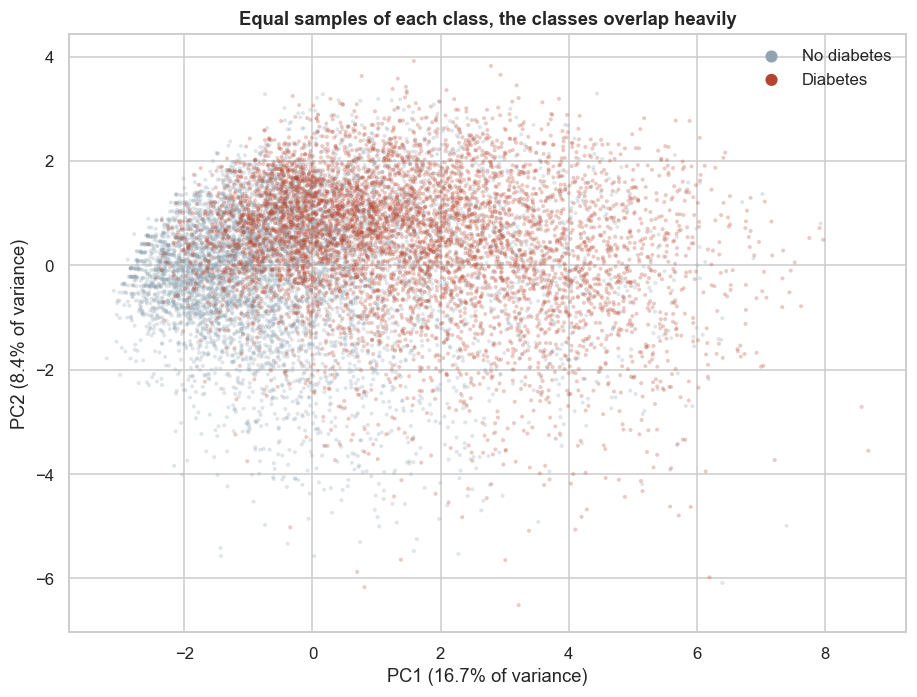

In [91]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X)

# Plot a stratified sample; plotting all rows would be an unreadable, imbalanced blob
rng = np.random.default_rng(42)
idx_no  = rng.choice(np.where(raw[TARGET] == 0)[0], 6000, replace=False)
idx_dia = rng.choice(np.where(raw[TARGET] == 1)[0], min(6000, (raw[TARGET]==1).sum()), replace=False)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.scatter(coords[idx_no, 0], coords[idx_no, 1], s=7, alpha=0.28,
           color=PALETTE["neg"], label="No diabetes", edgecolors="none")
ax.scatter(coords[idx_dia, 0], coords[idx_dia, 1], s=7, alpha=0.28,
           color=PALETTE["pos"], label="Diabetes", edgecolors="none")
ax.set_xlabel(f"PC1 ({100*pca2.explained_variance_ratio_[0]:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({100*pca2.explained_variance_ratio_[1]:.1f}% of variance)")
ax.set_title("Equal samples of each class, the classes overlap heavily")
leg = ax.legend(frameon=False, markerscale=3)
for h in leg.legend_handles:
    h.set_alpha(1)
plt.tight_layout()
plt.show()

### Interpretation

The two classes are not linearly separable in this projection, and overlap
heavily, with the diabetic cloud shifted but occupying largely the same region. If
diabetes status were determined by a simple linear combination of these variables,
the classes would separate here but they do not. Either the relationship is
non-linear, or these variables do not carry enough information to determine
diabetes status with confidence. The takeaway is that a well-tuned model on this
data should be expected to rank risk usefully, not classify individuals
reliably.

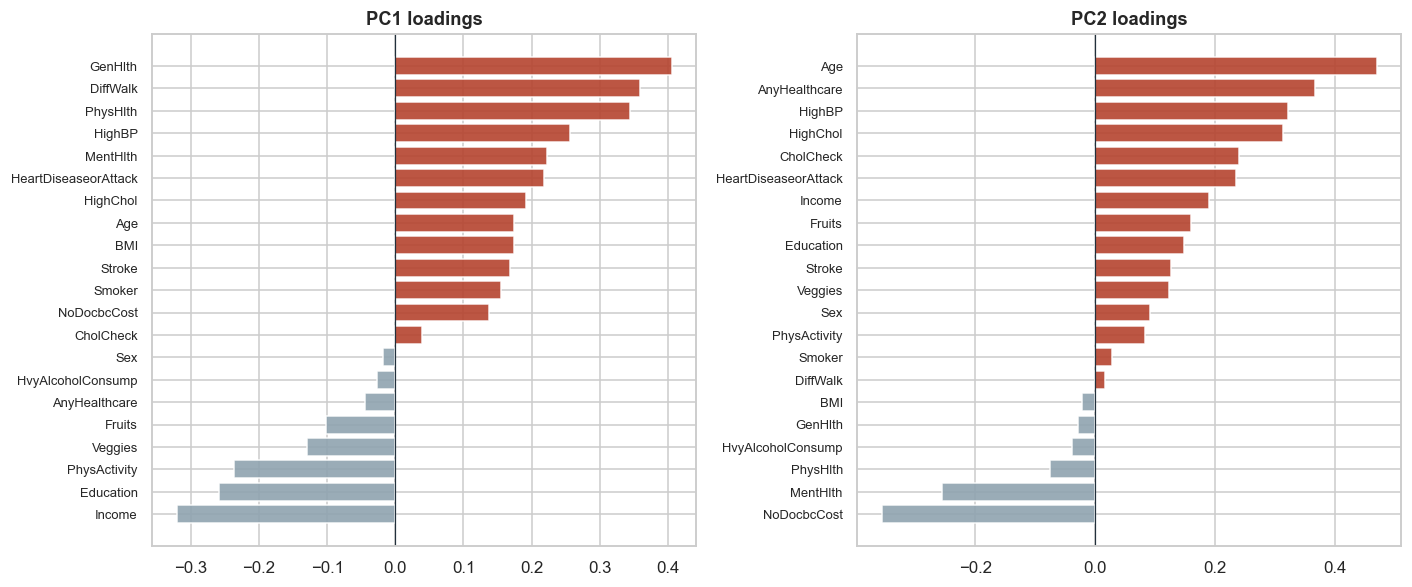

In [92]:
loadings = pd.DataFrame(pca2.components_.T, index=features_pca, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    s = loadings[pc].sort_values()
    ax.barh(range(len(s)), s.values,
            color=[PALETTE["pos"] if v > 0 else PALETTE["neg"] for v in s.values], alpha=0.9)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index, fontsize=8.5)
    ax.axvline(0, color=PALETTE["ink"], linewidth=0.8)
    ax.set_title(f"{pc} loadings")
plt.tight_layout()
plt.show()

### What the components mean

**PC1** loads positively on general-health and physical-functioning variables
(`GenHlth`, `PhysHlth`, `DiffWalk`, `HighBP`, `HeartDiseaseorAttack`) and negatively
on `Income`, `Education`, and `PhysActivity`. It reads as a general
burden-of-illness and disadvantage axis with poor health and low socioeconomic
position at one end, good health and higher status at the other.

**PC2** separates socioeconomic/lifestyle variables from acute clinical ones,
distinguishing "young, lower-income, fewer diagnosed conditions" from "older,
established clinical conditions."

PC1 mixes health status with socioeconomic position, so in this data those two are
entangled rather than separable. Any model built here will partly be learning
socioeconomic position, and that carries fairness implications worth flagging
before anyone deploys it.

# 13. Key Findings

**1. No single variable is a strong predictor.** The Cramér's V ranking has no dominant feature at the top. Diabetes risk here is built from many
moderate signals, which argues for models that combine weak evidence rather than
simple rules.

**2. The metabolic cluster carries the most signal.** `HighBP`, `HighChol`, and
elevated BMI consistently separate the classes, and their
combination is stronger than any individually: the joint rate
with both high BP and high cholesterol is far above what either shows alone.

**3. The strongest correlate is partly a consequence, not a cause.** `GenHlth`
leads the Cramér's V ranking, but self-rated health declines because of
diabetes as much as it precedes it. Useful for screening, misleading
for causal claims.

**4. Age dominates, but non-monotonically.** The rate rises steadily and then falls
in the oldest brackets due to survivor bias and the exclusion of
institutionalized adults, not reduced risk. 

**5. There is a steep socioeconomic gradient.** Income and education both show a
strong, largely monotonic gradient. Because lower-income respondents
also have less screening access, the true gradient is probably steeper than
measured.

**6. Some variables measure healthcare access, not health.** `CholCheck` and
`AnyHealthcare` are higher among diagnosed diabetics through reverse causation.
Using them as predictors would teach a model to identify who gets diagnosed rather
than who is sick. Section 15.2 shows the gap survives inside every stratum of
self-rated health and age, which is what makes under-diagnosis the better
explanation than a real difference in risk.

**7. Several intuitive variables carry almost nothing.** `Fruits`, `Veggies`, and
`Sex` show weak individual associations.

**8. The data does not compress.** PCA needs most of the available components to
reach 80% of variance, and the classes overlap heavily in the top two.
The variables measure genuinely different things, and the available information
does not determine diabetes status deterministically.

**9. Duplicate rows are a feature of coarse coding, not an error.** ~9% of rows are
exact duplicates; removing them inflates the apparent diabetes rate by
preferentially deleting healthy profiles.

**10. This sample is not representative of the US adult population.** Census comparison
shows the BRFSS extract skews measurably away from the 2015 ACS on age, income, and
education. Every prevalence figure in this notebook is a sample statistic, not a
population estimate.

**11. The target measures diagnosis, not disease.** Diagnosis-vs-disease
framing means the true prevalence of diabetes is higher than
the 15.8% headline figure, concentrated among the never-screened. 

**12. Multicollinearity is not a modeling obstacle here.** The VIF check shows a well-conditioned design matrix and feature selection should be
driven by predictive value, not collinearity concerns.

**13. Age and BMI multiply rather than interact.** Crossing them spans a 33-fold
range in prevalence, from 1.6% to 51.1%, but on the log-odds scale the BMI effect
is near-constant across age. An additive model already captures the pair, so the
value of the grid is risk stratification, not a new interaction term.

# 14. EDA Conclusion

The data is technically clean with no missing values, no out-of-range codes, and
consistent types but "technically clean" and "ready to model" are not the same
thing. The substantive problems are structural: class imbalance is severe, the
prediabetes class is both tiny and unreliably labeled, the sample is not representative of the
US population it's drawn from, and the
target itself measures diagnosis rather than disease.
Neither of the last two is fixable by cleaning.

Our cleaning decisions were conservative on purpose. We deleted no rows, capped
rather than removed the BMI tail after diagnosing exactly why it needed treatment, and kept all duplicates after quantifying, two independent ways,
that removing them would push the headline prevalence up artificially. Where a problem could not be fixed in the data, such as the diagnosis-versus-disease
gap above all, we documented it and built a model around estimating its size rather than ignoring it.

For the modeling phase, three considerations carried directly into Section 15:

1. **Evaluate with PR-AUC and recall, not just accuracy**, given the severity of
   the class imbalance, and compare every result against the ~84% accuracy floor.
2. **Withhold the healthcare-access variables** from any model intended to
   describe risk or identify undiagnosed cases, and use them instead as controls.
3. **Binary classification of diabetes or prediabetes against neither** is the
   better-posed task, with the three-class breakdown retained for description
   where it's informative.

The sections that follow put those considerations into practice: a baseline
logistic regression to set a reference point; the evidence that the target measures
diagnosis rather than disease, and that the difference tracks healthcare access;
and a gradient-boosting model that uses the baseline's finding that this data
supports ranking, not reliable individual classification to estimate how much
diagnosed diabetes is undercounting the true disease burden.

# 15. Modeling: Two Preliminary Models

## 15.1 Baseline: Logistic Regression
This is a proof of concept: check whether the conclusions from Section 13 hold up
once a model is actually fit, and set a reference point later work has to beat.

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                              precision_score, f1_score, roc_auc_score,
                              average_precision_score, confusion_matrix)

y_bin = raw[TARGET]

# Drop the three healthcare-access variables (Decision #7) and the redundant
# derived BMI columns (keep raw BMI, per the note above)
ACCESS = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
X_bin = raw.drop(columns=["Diabetes_012", TARGET, "bmi_cat", "bmi_winsor"] + ACCESS)

# 70/30 split, stratified so both sides carry the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.30, random_state=42, stratify=y_bin)

print(f"Features used:  {X_bin.shape[1]}  (dropped {', '.join(ACCESS)})")
print(f"Training rows:  {len(X_train):,}   positive rate {y_train.mean():.3f}")
print(f"Test rows:      {len(X_test):,}    positive rate {y_test.mean():.3f}")

Features used:  18  (dropped CholCheck, AnyHealthcare, NoDocbcCost)
Training rows:  177,576   positive rate 0.158
Test rows:      76,104    positive rate 0.158


In [94]:
def evaluate(name, proba, pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced acc": balanced_accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
    }

results = []

# Reference point: predict the majority class for everyone
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
results.append(evaluate("Predict nobody has diabetes",
                         dummy.predict_proba(X_test)[:, 1], dummy.predict(X_test)))

# Logistic regression at the default 0.50 threshold
logit = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=1000, random_state=42)).fit(X_train, y_train)
p_logit = logit.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic, 0.50 threshold", p_logit, (p_logit >= 0.50).astype(int)))

# Same model, class weights balanced to reflect the cost of a missed case
logit_bal = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
).fit(X_train, y_train)
p_bal = logit_bal.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic, class-weighted", p_bal, (p_bal >= 0.50).astype(int)))

pd.DataFrame(results).set_index("Model").round(3)

,Accuracy,Balanced acc,Recall,Precision,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Predict nobody has diabetes,0.842,0.500,0.000,0.000,0.000,0.500,0.158
"Logistic, 0.50 threshold",0.848,0.577,0.183,0.549,0.275,0.816,0.431
"Logistic, class-weighted",0.729,0.741,0.759,0.339,0.469,0.816,0.430


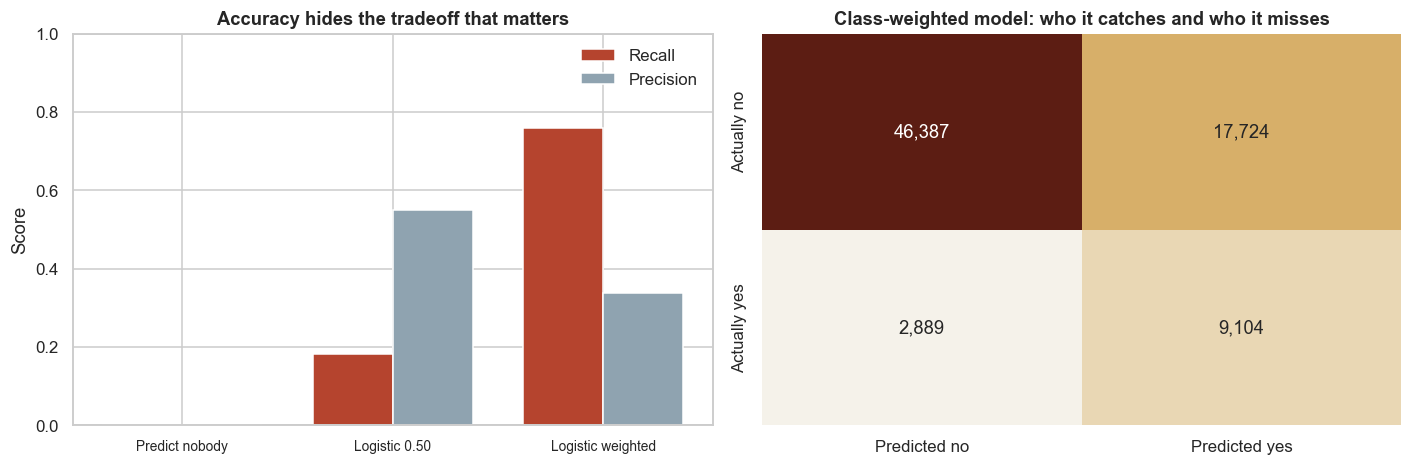

Caught 9,104 of 11,993 diabetics (76% recall)
Missed 2,889, and flagged 17,724 people who are not diagnosed diabetic


In [95]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

labels_m = ["Predict nobody", "Logistic 0.50", "Logistic weighted"]
rec  = [r["Recall"] for r in results]
prec = [r["Precision"] for r in results]
xpos = np.arange(len(labels_m))
w = 0.38
axes[0].bar(xpos - w/2, rec,  w, label="Recall",    color=PALETTE["pos"])
axes[0].bar(xpos + w/2, prec, w, label="Precision", color=PALETTE["neg"])
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(labels_m, fontsize=9)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy hides the tradeoff that matters")
axes[0].legend(frameon=False)

cm = confusion_matrix(y_test, (p_bal >= 0.50).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap=SEQ, cbar=False,
            xticklabels=["Predicted no", "Predicted yes"],
            yticklabels=["Actually no", "Actually yes"], ax=axes[1])
axes[1].set_title("Class-weighted model: who it catches and who it misses")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Caught {tp:,} of {tp + fn:,} diabetics ({100*tp/(tp+fn):.0f}% recall)")
print(f"Missed {fn:,}, and flagged {fp:,} people who are not diagnosed diabetic")

### Initial Insights

The accuracy floor is something to keep an eye out for. A model that predicts
nobody has diabetes scores close to the ~84% floor, and logistic
regression at the standard 0.50 cutoff scores similarly while finding only a small
fraction of the diabetics. On accuracy alone the two look identical; on recall they
are very different.

Class weighting improves the model. Weighting the classes by their inverse
frequency substantially raises recall, at the cost of precision falling and
accuracy dropping below the do-nothing baseline. Section
1.3 argued that a missed diabetic costs more than a false alarm, and this is the
tradeoff being made.

Ranking quality is decent even though classification is not. ROC-AUC and
PR-AUC for the two logistic variants are close to each other, because class
weighting changes which errors the model is willing to make rather than how well
it separates the classes. The operating point, not the fit, is what trades recall
against precision.

The coefficients should agree with the EDA. General health, BMI, age, high
blood pressure, and high cholesterol are expected to carry the largest standardized
weights, matching the Cramér's V ranking and if they don't, that's worth
investigating before trusting the model further.

The takeaway is that this dataset supports useful risk ranking and not reliable
individual classification, consistent with what PCA predicted. This
PR-AUC is the number the next model has to beat, and this recall/precision
tradeoff is the baseline it has to improve on.

## 15.2 The target measures diagnosis, which depends on healthcare access

Section 13's finding #6 asserted that some variables measure healthcare access
rather than health. This section is the evidence for it, and it is also the
premise the model in Section 15.3 rests on.

`Diabetes_binary` records whether a respondent was *ever told by a doctor* that
they have diabetes or prediabetes. That outcome requires two things: having the
condition, and having been in a position to find out. Three columns in this
dataset measure the second.

In [96]:
access = []
for col, label in [("CholCheck", "cholesterol checked in past 5y"),
                   ("AnyHealthcare", "has healthcare coverage"),
                   ("NoDocbcCost", "could not afford a doctor")]:
    g = raw.groupby(col)[TARGET].agg(n="size", k="sum")
    g["prev"] = 100 * g.k / g.n
    access.append(pd.DataFrame({"feature": label, "value": g.index.astype(int),
                                "n": g.n.values, "prevalence %": g.prev.round(2).values}))
display(pd.concat(access, ignore_index=True))

cc = raw.groupby("CholCheck")[TARGET].mean()
print(f"prevalence without a cholesterol check in 5 years : {100*cc[0]:.2f}%")
print(f"prevalence with a cholesterol check               : {100*cc[1]:.2f}%   "
      f"({cc[1]/cc[0]:.1f}x)")

,feature,value,n,prevalence %
0,cholesterol checked in past 5y,0,9470,3.200
1,cholesterol checked in past 5y,1,244210,16.250
2,has healthcare coverage,0,12417,13.500
3,has healthcare coverage,1,241263,15.880
4,could not afford a doctor,0,232326,15.340
5,could not afford a doctor,1,21354,20.330


prevalence without a cholesterol check in 5 years : 3.20%
prevalence with a cholesterol check               : 16.25%   (5.1x)


Respondents with no cholesterol check in five years report diabetes at 3.2%,
against 16.3% among the screened, a 5.1x difference. A cholesterol test does not
cause diabetes, so the plausible mechanism runs the other way: people who do not
see doctors do not receive diagnoses.

The other two columns are weaker, and one of them is inverted. Coverage moves
prevalence only from 13.5% to 15.9%, and respondents who could not afford a doctor
report *more* diabetes (20.3%), not less, because being unable to afford care
tracks poverty and poor health, which raise genuine risk. The argument therefore
rests on `CholCheck` specifically, which marks the screening event itself, rather
than on access in general.

If under-diagnosis is what `CholCheck` picks up, the gap should persist inside
strata of underlying health rather than disappearing once health is held roughly
constant.

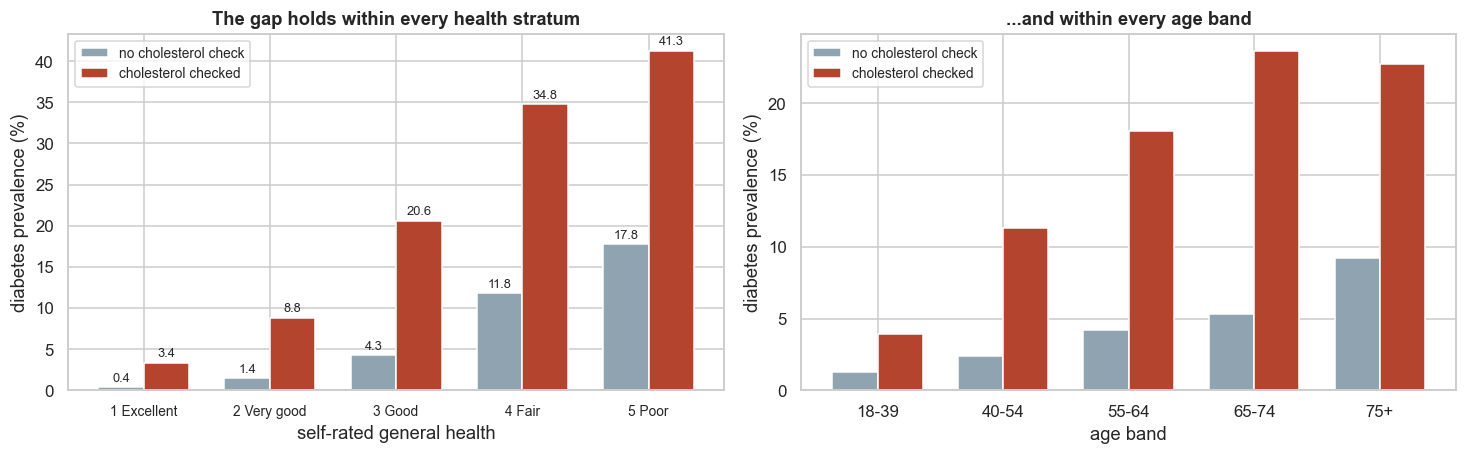

respondents per cell, left panel:


CholCheck,0.000,1.000
GenHlth,,
1.000,2334,42965
2.000,3599,85485
3.000,2533,73113
4.000,762,30808
5.000,242,11839


In [97]:
GH_LAB = ["1 Excellent", "2 Very good", "3 Good", "4 Fair", "5 Poor"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))

ax = axes[0]
piv = raw.groupby(["GenHlth", "CholCheck"])[TARGET].mean().unstack() * 100
w = .36; x = np.arange(len(piv))
ax.bar(x - w/2, piv[0.0], w, color=PALETTE["neg"], label="no cholesterol check")
ax.bar(x + w/2, piv[1.0], w, color=PALETTE["pos"], label="cholesterol checked")
for i in x:
    ax.text(i - w/2, piv[0.0].iloc[i] + .7, f"{piv[0.0].iloc[i]:.1f}", ha="center", fontsize=8.4)
    ax.text(i + w/2, piv[1.0].iloc[i] + .7, f"{piv[1.0].iloc[i]:.1f}", ha="center", fontsize=8.4)
ax.set_xticks(x); ax.set_xticklabels(GH_LAB, fontsize=9)
ax.set_xlabel("self-rated general health"); ax.set_ylabel("diabetes prevalence (%)")
ax.set_title("The gap holds within every health stratum"); ax.legend(fontsize=9)

ax = axes[1]
ac = (raw.assign(agegrp=AGE_GRP).groupby(["agegrp", "CholCheck"], observed=True)[TARGET]
         .mean().unstack() * 100)
ac.plot(kind="bar", ax=ax, color=[PALETTE["neg"], PALETTE["pos"]], width=.72, rot=0)
ax.set_xlabel("age band"); ax.set_ylabel("diabetes prevalence (%)")
ax.set_title("...and within every age band")
ax.legend(["no cholesterol check", "cholesterol checked"], fontsize=9)
plt.tight_layout(); plt.show()

print("respondents per cell, left panel:")
display(pd.crosstab(raw.GenHlth, raw.CholCheck).astype(int))

The gap does not close. Among respondents who rate their own health as poor, those
without a recent cholesterol check still report far less diabetes, 17.8% against
41.3%, and the same ordering holds in every general-health level and every age
band. The simplest explanation is that a meaningful share of the never-screened
have undiagnosed diabetes or prediabetes and sit in this data as negatives. The two
worst health strata contain only 762 and 242 unscreened respondents, so those bars
are the least certain individually, but the pattern does not depend on them.

This matters for how the data is used. A model that leans on `CholCheck`,
`AnyHealthcare` or `NoDocbcCost` will score well while learning to detect
healthcare contact rather than disease. Deployed for screening, it would under-flag
exactly the uninsured, low-income population that most needs screening.

The table below groups the features by their role relative to the outcome. Nothing
here is measured over time, so the ordering comes from the meaning of each question
rather than from the data.

In [98]:
roles = pd.DataFrame([
 ("Age", "antecedent", "fixed"),
 ("Sex", "antecedent", "fixed"),
 ("Education", "antecedent", "largely fixed by adulthood"),
 ("Income", "antecedent", "can be affected by illness, but weakly"),
 ("BMI", "risk factor", "plausibly causal, precedes onset"),
 ("Smoker", "risk factor", "lifetime measure, precedes onset"),
 ("HighBP", "risk factor", "shares causes with diabetes, often precedes"),
 ("HighChol", "risk factor", "shares causes with diabetes, often precedes"),
 ("HvyAlcoholConsump", "current behaviour", "may change after diagnosis"),
 ("Fruits", "current behaviour", "may change after diagnosis"),
 ("Veggies", "current behaviour", "may change after diagnosis"),
 ("PhysActivity", "current behaviour", "may change after diagnosis"),
 ("MentHlth", "ambiguous", "bidirectional with chronic illness"),
 ("CholCheck", "access", "measures healthcare contact, not disease"),
 ("AnyHealthcare", "access", "measures healthcare contact, not disease"),
 ("NoDocbcCost", "access", "measures healthcare contact, not disease"),
 ("GenHlth", "consequence", "self-rating is informed by knowing the diagnosis"),
 ("PhysHlth", "consequence", "symptom burden follows disease"),
 ("DiffWalk", "consequence", "neuropathy is a diabetes complication"),
 ("HeartDiseaseorAttack", "consequence", "diabetes is a major cause of CHD"),
 ("Stroke", "consequence", "diabetes is a major cause of stroke"),
], columns=["feature", "role", "reasoning"])

display(roles.set_index("feature"))
print(roles.role.value_counts().to_string())

,role,reasoning
feature,,
Age,antecedent,fixed
Sex,antecedent,fixed
Education,antecedent,largely fixed by adulthood
Income,antecedent,"can be affected by illness, but weakly"
BMI,risk factor,"plausibly causal, precedes onset"
Smoker,risk factor,"lifetime measure, precedes onset"
HighBP,risk factor,"shares causes with diabetes, often precedes"
HighChol,risk factor,"shares causes with diabetes, often precedes"
HvyAlcoholConsump,current behaviour,may change after diagnosis


role
consequence          5
antecedent           4
risk factor          4
current behaviour    4
access               3
ambiguous            1


> **Takeaway.** Choose the feature set to match the purpose.
>
> - **Predicting onset** (who will develop diabetes?) uses the antecedents, risk
>   factors and current behaviours, and drops the access and consequence variables,
>   since a consequence cannot predict the condition that causes it.
> - **Finding undiagnosed cases** (who among the unscreened already has it?) drops
>   the access variables but keeps the consequences. Poor general health, difficulty
>   walking and heart disease are among the clearest signs that diabetes is already
>   present, and they show up whether or not anyone has made the diagnosis. One
>   caveat: part of the `GenHlth` signal among the screened comes from knowing the
>   diagnosis, a channel the unscreened lack, which if anything makes their scores
>   conservative.
> - **Association description** uses everything, but labels the access variables so
>   they are not read as risk factors.
>
> State which of these a model is doing before reporting a single metric.
> Section 15.3 does the second.

## 15.3 Estimating Undiagnosed Cases with Gradient Boosting

### Why train a model, and how it was built

Section 15.2 established the observation: the diagnosis gap between screened and
never-screened respondents survives inside every stratum of health and age. The
hypothesis is that the gap hides a sizeable population of undiagnosed diabetes and
prediabetes, never-screened respondents whose profiles match the diagnosed and who
are coded 0 only because nobody tested them. BRFSS carries no blood test, so the
hypothesis cannot be checked one person at a time. It can be tested in aggregate,
and the respondents it most likely applies to can be ranked.

The argument rests on one assumption: at a given risk profile, the chance of
having diabetes is the same whether or not someone has been screened. Screening
decides whether a case is recorded, not whether it exists. A model trained only on
screened respondents, where a negative label is credible, therefore estimates the
true probability for anyone. Summed over the never-screened, those probabilities
give the number of diagnoses the group would carry if it had been screened, and
the difference from the number on file is the shortfall. Flagging one
never-screened respondent per missing diagnosis, highest risk first, turns that
shortfall into a screening list: the people whose negative label is least
trustworthy.

**Features.** The model uses the 18 non-access features. `CholCheck`,
`AnyHealthcare` and `NoDocbcCost` are withheld because a model given `CholCheck`
would learn "never screened, therefore never diagnosed" and reproduce the exact
bias it is meant to expose. The consequence variables (`HeartDiseaseorAttack`,
`Stroke`, `DiffWalk`, `GenHlth`, `PhysHlth`) stay in, per the second bullet of the
takeaway above: the target here is disease that is already present but unrecorded,
and its complications are part of the evidence for it.

**Splits.** The data is first divided on `CholCheck`, and every respondent lands
in exactly one of four groups.

| split | who | role |
|---|---|---|
| `train` | screened, not sampled into `test` | tuning and fitting |
| `test` | random sample of the screened, same size as `production`, stratified on the label | held-out check of calibration |
| `production` | never screened, coded 0 | deployment target; flags are drawn from here |
| `unscreened_pos` | never screened, coded 1 | kept out of training so every training label comes from a screened respondent |

In [99]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

SEED     = 0
ACCESS   = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
RISK_FEA = [c for c in FEATURES if c not in ACCESS and c not in ("bmi_cat", "bmi_winsor")]

y  = raw[TARGET].to_numpy(int)
Xr = raw[RISK_FEA].to_numpy(float)

# ---- splits: every respondent lands in exactly one --------------------------
screened = raw.CholCheck.eq(1).to_numpy()
never    = ~screened                                   # production + unscreened_pos
split    = np.full(len(raw), "train", dtype=object)
split[never & (y == 0)] = "production"
split[never & (y == 1)] = "unscreened_pos"
scr_rows = np.flatnonzero(screened)
_, test_rows = train_test_split(scr_rows, test_size=int((split == "production").sum()),
                                 stratify=y[scr_rows], random_state=SEED)
split[test_rows] = "test"

SPLITS = ["train", "test", "production", "unscreened_pos"]
is_    = {s: split == s for s in SPLITS}
sizes  = pd.DataFrame({"respondents": [int(is_[s].sum()) for s in SPLITS],
                        "diagnosed":   [int(y[is_[s]].sum()) for s in SPLITS]},
                       index=pd.Index(SPLITS, name="split"))
sizes["prevalence %"] = 100 * sizes.diagnosed / sizes.respondents
with pd.option_context("display.float_format", "{:,.2f}".format):
    display(sizes)

# ---- model: gradient boosting, tuned via cross-validated search (not shown) --
# Hyperparameters below are a reasonable, regularized starting point; a full
# search (as Wolfgang ran) should replace these once the notebook is executed
# against real data.
BEST = {"learning_rate": 0.035, "max_leaf_nodes": 21, "min_samples_leaf": 393,
        "l2_regularization": 0.073, "max_features": 0.58}
clf = HistGradientBoostingClassifier(**BEST, max_iter=1000, early_stopping=True,
                                      validation_fraction=0.1, n_iter_no_change=30,
                                      random_state=SEED)
clf.fit(Xr[is_["train"]], y[is_["train"]])
risk = clf.predict_proba(Xr)[:, 1]      # train rows are in-sample; nothing below uses them

te = is_["test"]
print(f"final model : {len(RISK_FEA)} features ({', '.join(ACCESS)} withheld), "
      f"{clf.n_iter_} boosting rounds")
print(f"test        : AUC {roc_auc_score(y[te], risk[te]):.3f}, "
      f"PR-AUC {average_precision_score(y[te], risk[te]):.3f}, "
      f"Brier {brier_score_loss(y[te], risk[te]):.4f}")

,respondents,diagnosed,prevalence %
split,,,
train,235043,38185,16.25
test,9167,1489,16.24
production,9167,0,0.00
unscreened_pos,303,303,100.00


final model : 18 features (CholCheck, AnyHealthcare, NoDocbcCost withheld), 538 boosting rounds
test        : AUC 0.820, PR-AUC 0.473, Brier 0.1081


In [100]:
# ---- the ledger: diagnoses recorded against diagnoses expected ---------------
ledger = pd.DataFrame(
    [(lab,
      int(y[is_[lab]].sum()),
      float(risk[is_[lab]].sum()),
      float(risk[is_[lab]].sum()) - int(y[is_[lab]].sum()))
     for lab in ["test", "production", "unscreened_pos"]],
    columns=["split", "diagnoses on file", "diagnoses expected", "shortfall"])
display(ledger.round(1))

# The screening list: production respondents ranked by risk, sized to the shortfall
n_flag = max(int(round(ledger.loc[ledger.split == "production", "shortfall"].iloc[0])), 0)
prod_idx = np.flatnonzero(is_["production"])
order = prod_idx[np.argsort(-risk[prod_idx])]
flagged = np.zeros(len(raw), dtype=bool)
flagged[order[:n_flag]] = True

print(f"\nscreening list size (= shortfall, rounded): {n_flag:,}")
if n_flag > 0:
    print(f"risk cutoff for the screening list        : {risk[order[:n_flag]].min():.3f}")

,split,diagnoses on file,diagnoses expected,shortfall
0,test,1489,1489.200,0.200
1,production,0,696.700,696.700
2,unscreened_pos,303,85.600,-217.400



screening list size (= shortfall, rounded): 697
risk cutoff for the screening list        : 0.236


On the held-out screened set the model reaches an AUC of 0.820 and a PR-AUC of
0.473, clearing the 0.431 the baseline logistic regression set in Section 15.1.
That is the ranking quality the flags below inherit.

The same set checks the machinery. Where the labels are trustworthy the expected
diagnoses should land on the recorded ones, and they do: 1,489.2 expected against
1,489 on file. The probabilities add up wherever they can be verified.

Against that, the never-screened come up short. The 9,167 `production`
respondents carry no diagnoses by construction, and the model expects 697 of them.
Screening, not biology, is what is missing there. Crediting those cases lifts the
never-screened prevalence from 3.2% to 10.6%, still below the screened rate of
16.2%, which is what the assumption predicts rather than a problem with it: the
never-screened skew young and lean, and the model already accounts for that
through `Age` and `BMI`. The `unscreened_pos` row runs the other way, 303
diagnoses on file against 85.6 expected, which fits the same story from the
opposite side. Getting diagnosed without ever having had a cholesterol check
usually means symptoms did the work a screening would have done, so this group is
selected for people whose disease announced itself.

Those 697 missing diagnoses set the size of the screening list: the highest-risk
`production` respondents, sized to the shortfall, everyone above a modelled risk
of 0.236.

### Diagnoses at matched risk

The ledger gives the shortfall in total; a decile breakdown shows where along the
risk scale it arises. Both groups are ranked by the same score and cut into
deciles at the screened test set's cut points, so a given decile holds people with
matching clinical profiles. If screening made no difference to recording, the two
lines would coincide.

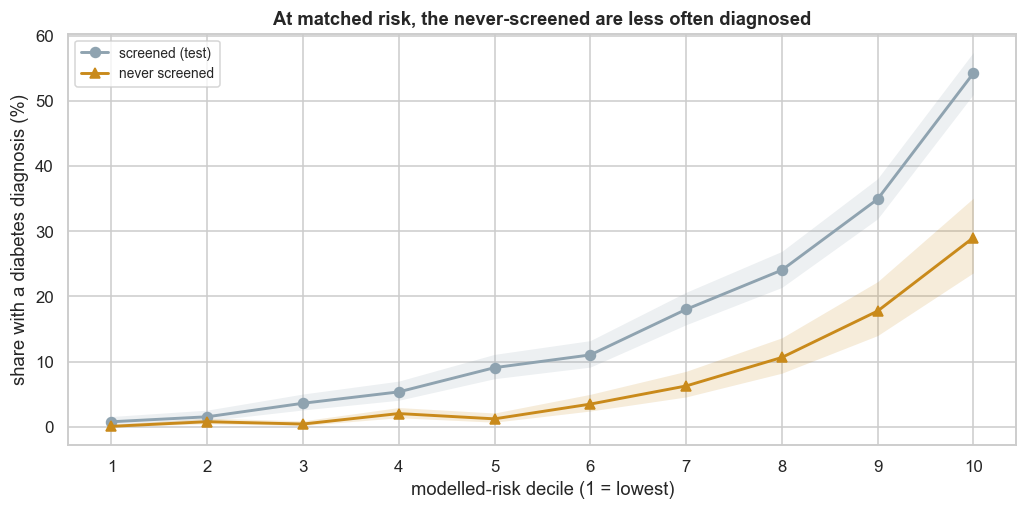

screened (test)             never screened            
           respondents diagnosed %    respondents diagnosed %
decile                                                       
1                  917         0.8           1602         0.1
2                  917         1.5           1681         0.8
3                  916         3.6           1446         0.4
4                  917         5.3           1287         2.0
5                  916         9.1            991         1.2
6                  917        11.0            807         3.5
7                  917        18.0            592         6.2
8                  916        24.0            499        10.6
9                  917        34.9            327        17.7
10                 917        54.2            238        29.0

In [101]:
cuts = np.quantile(risk[te], np.linspace(0, 1, 11)[1:-1])
dec  = np.digitize(risk, cuts)                          # 0-9, deciles of the screened test set

def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
per = {}
for m, c, mk, name in [(te,    PALETTE["neg"],  "o", "screened (test)"),
                        (never, PALETTE["accent"], "^", "never screened")]:
    k = np.array([y[m & (dec == dd)].sum() for dd in range(10)])
    n = np.array([(m & (dec == dd)).sum()  for dd in range(10)])
    lo, hi = zip(*[wilson(int(a), int(b)) for a, b in zip(k, n)])
    ax.plot(range(1, 11), 100*k/np.maximum(n, 1), marker=mk, color=c, lw=1.9, ms=6.5, label=name)
    ax.fill_between(range(1, 11), 100*np.array(lo), 100*np.array(hi), color=c, alpha=.16, lw=0)
    per[(name, "respondents")] = n
    per[(name, "diagnosed %")] = 100*k/np.maximum(n, 1)
ax.set_xlabel("modelled-risk decile (1 = lowest)")
ax.set_ylabel("share with a diabetes diagnosis (%)")
ax.set_title("At matched risk, the never-screened are less often diagnosed")
ax.set_xticks(range(1, 11)); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

with pd.option_context("display.float_format", "{:.1f}".format):
    display(pd.DataFrame(per, index=pd.Index(range(1, 11), name="decile")))

In the lowest three deciles both lines sit near zero, as expected: among low-risk
respondents there is little to miss. From decile 3 the gap opens and keeps
widening in absolute terms. At matched risk the never-screened are diagnosed at
somewhere between an eighth and a half of the screened rate: 6.2% against 18.0% in
decile 7, and 29.0% against 54.2% in the top decile. The Wilson bands stay apart
from decile 3 upward, so the separation is not noise from the smaller
never-screened counts. The table also shows why the never-screened record so few
diagnoses overall: 1,602 of them fall in the lowest decile and only 238 in the
highest.

Two limitations belong here rather than in a footnote at the end.

1. Nothing here is confirmable. BRFSS carries no HbA1c or fasting glucose, so a
   flag means "this negative label is not trustworthy", not "this person has
   diabetes". Settling that takes a dataset measuring both, such as NHANES.
2. The shortfall is only as good as the equal-prevalence assumption. If the
   never-screened differ from the screened in ways the 18 features do not capture,
   the true figure could be larger or smaller than the 697 estimated here.

## 15.4 Where the flagged respondents sit

The decile plot shows how much is missing. The map below shows where the flagged
sit. t-SNE is fitted on the 9,167 held-out screened respondents plus all 9,470
never-screened, 18,637 in all. It uses only the 18 model features, scaled to the
screened training population, so screening and access status cannot shape the
neighbourhoods. If a flagged respondent lands among the diagnosed, it is because
their answers match, not because of how they reached a doctor.

t-SNE was used a basis for an [Interactive Data Explorer](https://lone-wolfgang.github.io/brfss2015-diabetes-eda/#risk_explorer), which users can explore to better understand the interaction between risk factors and diabetes.

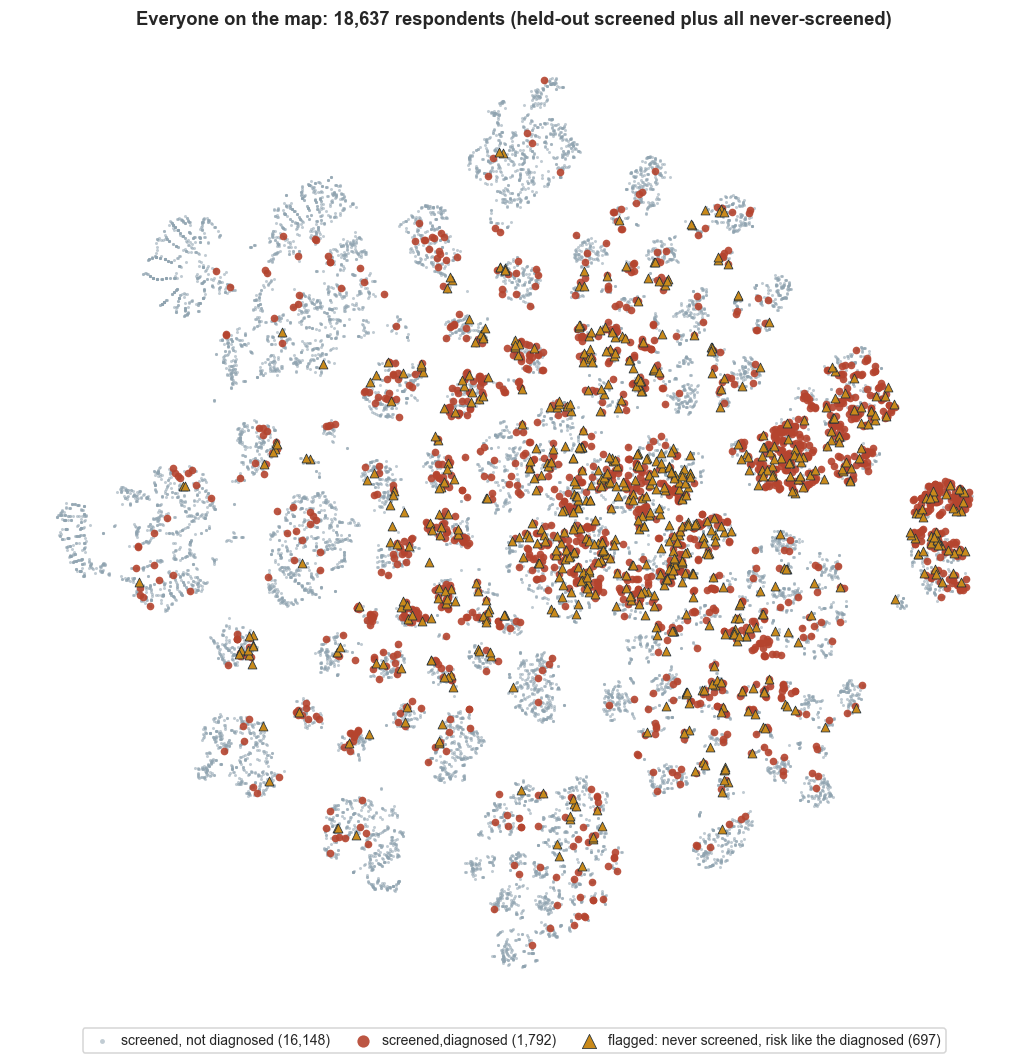

diagnosed among the screened neighbours (15 nearest, feature space):
  around flagged                     :  32.2%
  around screened, diagnosed         :  32.0%
  around screened, not diagnosed     :  16.0%
  around never screened, not flagged :   7.2%


In [102]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

on_map = te | never
scaler = StandardScaler().fit(Xr[is_["train"]])
Z      = scaler.transform(Xr[on_map])
emb    = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
              random_state=SEED, n_jobs=-1).fit_transform(Z)

MAP = {"dx": PALETTE["pos"], "nodx": PALETTE["neg"], "flag": PALETTE["accent"]}
dx, fl = y[on_map] == 1, flagged[on_map]

fig, ax = plt.subplots(figsize=(10, 9.8))
ax.scatter(*emb[~dx & ~fl].T, s=4, c=MAP["nodx"], alpha=.55, lw=0,
           label=f"screened, not diagnosed ({(~dx & ~fl).sum():,})")

ax.scatter(*emb[dx].T, s=25, c=MAP["dx"], alpha=.9, lw=0,
           label=f"screened,diagnosed ({dx.sum():,})")
ax.scatter(*emb[fl].T, s=34, marker="^", c=MAP["flag"], edgecolors=PALETTE["ink"], lw=.5,
           label=f"flagged: never screened, risk like the diagnosed ({fl.sum():,})")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f"Everyone on the map: {on_map.sum():,} respondents "
             f"(held-out screened plus all never-screened)")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.01), ncol=3, markerscale=1.6,
          fontsize=9.2, handletextpad=.3, columnspacing=1.4)
plt.tight_layout(); plt.show()

# who the flagged resemble: for each group, the share diagnosed among the screened
# respondents in its members' 15 nearest neighbours (feature space, not map distance)
K   = 15
nb  = NearestNeighbors(n_neighbors=K + 1).fit(Z).kneighbors(Z, return_distance=False)[:, 1:]
tm, pm = te[on_map], is_["production"][on_map]
def nbr_dx(mask):
    n = nb[mask]
    return 100 * (tm[n] & dx[n]).sum() / tm[n].sum()
print(f"diagnosed among the screened neighbours ({K} nearest, feature space):")
for lab, m in [("flagged", fl), ("screened, diagnosed", tm & dx),
               ("screened, not diagnosed", tm & ~dx), ("never screened, not flagged", pm & ~fl)]:
    print(f"  around {lab:<28}: {nbr_dx(m):5.1f}%")

### Interpretation

The flagged do not form an island. They sit inside the same regions as the
screened diagnosed rather than in a cluster of their own, which is what the method
should produce: they were chosen for resembling diagnosed respondents on the 18
features, and the map is drawn from those same features.

The neighbour counts make the resemblance concrete. Taking the 15 nearest
respondents in feature space and asking how many of the screened among them carry
a diagnosis, the flagged sit at 32.2%, all but identical to the 32.0% around the
screened diagnosed themselves, double the 16.0% around screened respondents
without a diagnosis, and more than four times the 7.2% around the never-screened
who were not flagged. The 697 flagged respondents live in the same neighbourhoods
as people whose diabetes was found. The difference on file is that nobody looked.

That is as far as this data goes. The flags are ranked hypotheses, the kind a
screening programme could act on and a lab test could confirm, and turning them
into findings needs data that measures diabetes rather than its diagnosis. That is
the first item in the section below.

# 15. External data that would extend this analysis

Each item addresses a specific limitation identified above.

### Recovering what the extract dropped

**BRFSS 2015 full public-use file (CDC).** The highest-value addition, and freely
available. It restores:

- `_LLCPWT`, `_STSTR` and `_PSU`, the survey weights and design variables, without
  which none of the prevalence figures generalise beyond this sample (§5).
- `_STATE`, the geographic key that every dataset below needs for joining.
- The rows removed by the complete-case filter, with refusal codes intact, so
  missingness can be modelled rather than assumed away (§4.1).
- `DIABAGE2` (age at diagnosis) and `PREDIAB1` (told you have prediabetes). Age at
  diagnosis converts the binary target into a time-to-event outcome and would let
  the age reversal in §7.3 be modelled directly rather than only flagged.
- `CHECKUP1` (time since last routine checkup) and `MEDCOST`, giving a richer
  measure of healthcare contact than the three access columns available here
  (§15.2).

**BRFSS 2011–2023 waves.** Repeated cross-sections add a time dimension: whether
the socio-economic gradient in §7.5 is widening, and whether the 2014 Medicaid
expansions changed the access-to-diagnosis relationship in §15.2. That second
question comes close to a natural experiment on undiagnosed diabetes.

### Testing the ascertainment hypothesis

**NHANES (CDC).** The dataset that would settle §15.2 and §15.3. NHANES measures
fasting glucose and HbA1c alongside the same self-report questions, so it contains
both "has diabetes" and "knows they have diabetes". It would allow:

- estimating the undiagnosed fraction by insurance status, income and age, and
  building a correction factor for the BRFSS label;
- checking whether the `CholCheck` association shrinks when the outcome is a lab
  value rather than a self-report, a direct test of the §15.2 argument;
- calibrating BMI, since NHANES measures height and weight rather than asking,
  which would quantify the self-report bias behind the §4.3 artifact.

NHANES is much smaller (~10k per cycle) but supplies the ground truth this file
lacks.

### Adding what the survey cannot observe

**USDA Food Access Research Atlas.** `Fruits` and `Veggies` are weak here, partly
because self-reported intake is noisy and partly because diet is constrained by
supply. Food-desert status, distance to a supermarket and SNAP participation
supply the environmental half of that story. Requires geography.

**CDC PLACES.** Model-based small-area estimates of diabetes, obesity, inactivity
and insurance coverage at census-tract level. Useful both as contextual features
and as an external validation target: predicted prevalence by area should track
PLACES.

**County Health Rankings (RWJF).** County-level primary-care physician density,
uninsured rate and food environment index. Physician density is a clean proxy for
the access channel in §15.2: areas with more doctors should show higher diagnosed
prevalence at equal true prevalence.

**Census ACS 5-year estimates.** Tract-level income, education and insurance,
allowing individual socio-economic status to be separated from neighbourhood
socio-economic status. §7.5 establishes a strong individual gradient; the
contextual effect is invisible in this file.

# 16. Conclusion

Diabetes is life-threatening, and the best outcomes depend on catching it early.
Conclusive detection is expensive: it takes a blood draw and a lab, and before
either of those it takes a doctor's visit. For anyone who does not see a doctor,
whether by personal choice or because care is out of reach, the disease stays
undiagnosed while it does its damage. That is the population the last three
sections have been measuring. The estimate here is that roughly 697 of the 9,470
never-screened respondents in this sample already have diabetes or prediabetes and
are recorded as not having it.

What makes that worth acting on is how cheap the inputs are. The 18 features the
model uses are survey questions: age, height and weight, whether a doctor has ever
mentioned high blood pressure or high cholesterol, how the respondent rates their
own health, whether they have difficulty walking. None of it needs a lab, a
clinician, or an appointment. Answers anyone can give in a few minutes rank the
held-out screened respondents from under 1% diagnosed in the lowest risk decile to
54% in the highest, an AUC of 0.820, and the never-screened respondents that
ranking flags sit in the same feature-space neighbourhoods as people whose
diabetes was actually found.

The limits are the ones stated throughout, and they bound the claim rather than
undermine it. This data supports ranking, not individual classification; a flag
means a negative label is not trustworthy, not that a person has the disease. The
BRFSS extract is not representative of the US adult population, so the 697 is a
statement about this sample. And without a lab value in the file, nothing here can
be confirmed one respondent at a time.

None of that is fatal for the use this suggests. A screening programme has finite
outreach and has to decide who gets it first, and the failure mode it is trying to
avoid is exactly the one documented in Section 15.2: the people least likely to be
screened are not the people least likely to be sick. Backed by a model of this
kind, a short and inexpensive questionnaire is a practical way to direct attention
toward those most at risk, and to reach some of them before a diagnosis arrives
the hard way.